<a href="https://colab.research.google.com/github/Gkulatheja/bias-unbiased-steriotypical-detection/blob/main/master_Copy_of_final_cut_multi_model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Create a Google Colab compatible Jupyter notebook (.ipynb) that implements a multimodal AI content detection system. The system should combine a trained RoBERTa model for text detection and a trained EfficientNet-B0 model for image detection using a late fusion approach. The notebook should include sections for environment setup, library installation, dataset preparation (assuming "images/real" and "images/fake" folders for images and a "text_data.csv" file with 'text' and 'label' columns), training of both models, late fusion implementation, real-time testing, performance evaluation (accuracy, confusion matrices), sample tests, and an interactive user interface. The final deliverable is the complete .ipynb notebook and a README file.

## Environment setup and library installation

### Subtask:
Set up the Google Colab environment and install necessary libraries like PyTorch, Transformers, and TensorFlow.


**Reasoning**:
Install the required libraries for the project.



In [ ]:
!pip install torch transformers tensorflow

## Dataset preparation

### Subtask:
Define paths to the image and text datasets, load them, and perform any necessary preprocessing.


**Reasoning**:
Define paths, create dummy data if necessary, load text data, and create image file paths and labels.



In [ ]:
# Updated dataset preparation to handle a single image zip and a text CSV file

import os
import pandas as pd
import numpy as np
import requests
import zipfile
from PIL import Image # Import Image for the Dataset class
import io # Import io for reading text data from zip

# 1. Define variables for the paths
# IMPORTANT: Upload your image.zip file and your text data CSV file to your Colab environment first.
# You can do this by clicking the folder icon on the left sidebar,
# then the upload icon, and selecting your files.
# Once uploaded, the files should be in the default Colab content directory,
# which is usually '/content/'.

image_zip_path = '/content/images.zip'  # Replace with the actual name of your uploaded image zip file (e.g., '/content/your_images.zip')
text_data_path = '/content/text_dataset.csv' # Replace with the actual name of your uploaded text CSV file (e.g., '/content/your_text_data.csv')

# Directories where images will be extracted
image_real_dir = 'extracted_images/real'
image_fake_dir = 'extracted_images/fake'


# Clean up existing directories to ensure a clean start
if os.path.exists('extracted_images'):
    import shutil
    shutil.rmtree('extracted_images')
if os.path.exists('images'): # Clean up previous dummy image directories if they exist
    import shutil
    shutil.rmtree('images')


# Create image extraction directories
os.makedirs(image_real_dir, exist_ok=True)
os.makedirs(image_fake_dir, exist_ok=True)

# --- Image Data Handling ---
print("Handling image data...")
image_paths = []
image_labels = []

try:
    if os.path.exists(image_zip_path):
        with zipfile.ZipFile(image_zip_path, 'r') as zip_ref:
            # Assuming your zip file contains 'real' and 'fake' folders at the top level,
            # and images within those folders (e.g., images.zip -> real/image1.png, fake/image2.jpg)
            # If your zip structure is different, you may need to adjust the extraction logic.
            print(f"Extracting images from {image_zip_path}...")
            for member in zip_ref.namelist():
                # Check if the member is a file (not a directory) and is inside 'real' or 'fake' folders
                if not member.endswith('/'): # Check if it's a file
                    if member.startswith('real/'):
                        # Extract to the new real directory
                        zip_ref.extract(member, 'extracted_images/')
                    elif member.startswith('fake/'):
                        # Extract to the new fake directory
                        zip_ref.extract(member, 'extracted_images/')
            print("Image extraction complete.")

            # 3. For the image data, create lists of file paths after extraction
            # This code assumes your real images are in 'extracted_images/real' and fake images are in 'extracted_images/fake'.
            # It will find all .jpg, .png, and .jpeg files in these directories (case-insensitive).
            real_image_paths = [os.path.join(image_real_dir, f) for f in os.listdir(image_real_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            fake_image_paths = [os.path.join(image_fake_dir, f) for f in os.listdir(image_fake_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

            image_paths = real_image_paths + fake_image_paths

            # 4. Create labels for the image data
            image_labels = [0] * len(real_image_paths) + [1] * len(fake_image_paths)

            # 6. Perform initial preprocessing for image data (basic file path validation)
            print("\nNumber of real image paths found:", len(real_image_paths))
            print("Number of fake image paths found:", len(fake_image_paths))
            print("Total number of image paths:", len(image_paths))
            print("Total number of image labels:", len(image_labels))

            # Basic validation: Check if the number of paths matches the number of labels
            if len(image_paths) != len(image_labels):
                print("Warning: Number of image paths does not match the number of image labels.")
                # If mismatch, truncate paths/labels to the minimum length to avoid errors
                min_len = min(len(image_paths), len(image_labels))
                image_paths = image_paths[:min_len]
                image_labels = image_labels[:min_len]
                print(f"Truncated to {min_len} samples to match paths and labels.")


            # Display a few sample image paths and labels
            print("\nSample image paths and labels:")
            for i in range(min(5, len(image_paths))):
                print(f"Path: {image_paths[i]}, Label: {image_labels[i]}")

    else:
        print(f"Warning: Image zip file not found at {image_zip_path}. Skipping image data loading.")
        # You might want to add logic here to handle cases where the zip file is not provided,
        # e.g., if images are already extracted in the expected directory structure.
        # For now, it will proceed with empty image_paths and image_labels.

except FileNotFoundError:
    print(f"Error: Image zip file not found at {image_zip_path}. Please upload your zip file.")
except zipfile.BadZipFile:
    print(f"Failed to extract images from {image_zip_path}: Bad zip file.")
except Exception as e:
    print(f"An error occurred during image extraction: {e}")


# --- Text Data Handling ---
print("\nHandling text data...")
text_df = None # Initialize text_df to None

try:
    if os.path.exists(text_data_path):
        text_df = pd.read_csv(text_data_path)
        # Ensure 'text' and 'label' columns exist
        if 'text' in text_df.columns and 'label' in text_df.columns:
            print("Text data loaded successfully:")
            display(text_df.head())
            # Perform initial preprocessing for text data (checking for missing values)
            print("\nChecking for missing values in text data:")
            print(text_df[['text', 'label']].isnull().sum()) # Only check relevant columns
            # Optional: Drop rows with missing text or label if necessary
            # text_df.dropna(subset=['text', 'label'], inplace=True)
            # print(f"After dropping rows with missing values: {len(text_df)} rows remaining.")
        else:
            print(f"Error: CSV file '{text_data_path}' must contain 'text' and 'label' columns.")
            text_df = None
    else:
        print(f"Warning: Text data CSV file not found at {text_data_path}. Skipping text data loading.")
        # You might want to add logic here to handle cases where the CSV file is not provided.
        # For now, text_df will remain None.


except FileNotFoundError:
    print(f"Error: Text data CSV file not found at {text_data_path}. Please upload your CSV file.")
    text_df = None
except Exception as e:
    print(f"An error occurred during text data handling: {e}")


# --- Proceed to model training only if data was loaded successfully ---
# The subsequent cells for training, fusion, evaluation, etc. will use
# the 'text_df', 'image_paths', and 'image_labels' variables prepared here.
# If text_df is None, text model training will likely fail.
# If image_paths or image_labels are empty, image model training will fail or be trivial.

# You would now typically proceed to the RoBERTa and EfficientNet training cells.
# Ensure you run this cell after uploading your files and before training the models.

Handling image data...
Extracting images from /content/images.zip...
Image extraction complete.

Number of real image paths found: 38
Number of fake image paths found: 40
Total number of image paths: 78
Total number of image labels: 78

Sample image paths and labels:
Path: extracted_images/real/Agal.jpg, Label: 0
Path: extracted_images/real/images (1).jpeg, Label: 0
Path: extracted_images/real/download (12).jpeg, Label: 0
Path: extracted_images/real/download (17).jpeg, Label: 0
Path: extracted_images/real/images (9).jpeg, Label: 0

Handling text data...
Text data loaded successfully:


,text,label
0,The capital of France is Paris,0
1,Water boils at 100 degrees Celsius at standard...,0
2,The human heart has four chambers: two atria a...,0
3,The sun is a star located at the center of the...,0
4,Mount Everest is the highest mountain above se...,0



Checking for missing values in text data:
text     0
label    0
dtype: int64


## Roberta model training (text)

### Subtask:
Set up and train the RoBERTa model for text-based AI content detection. This will involve tokenization, model configuration, training loop, and saving the trained model.


**Reasoning**:
Split the text data, tokenize it, create PyTorch Datasets and DataLoaders, define the RoBERTa model, set up the optimizer and loss function, implement the training loop with validation, and save the trained model.



In [ ]:
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn import CrossEntropyLoss
from tqdm.auto import tqdm
from torch.optim import AdamW # Corrected import location
import pandas as pd # Import pandas

# 1. Split the text_df DataFrame into training and validation sets
if text_df is None or len(text_df) < 2:
    print("Error: Text data is not available or too small for training and validation split.")
    train_dataloader = None
    val_dataloader = None
    model = None
else:
    # Drop rows with missing labels before splitting
    text_df_cleaned = text_df.dropna(subset=['text', 'label']).copy()
    text_df_cleaned['label'] = text_df_cleaned['label'].astype(int) # Ensure labels are integers


    train_size = int(0.8 * len(text_df_cleaned))
    val_size = len(text_df_cleaned) - train_size

    # Adjust sizes if one becomes zero due to small total size
    if train_size == 0 and val_size > 0:
        train_size = 1
        val_size -= 1
    elif val_size == 0 and train_size > 0:
        val_size = 1
        train_size -= 1


    if train_size == 0 or val_size == 0:
        print(f"Error: Cannot create train/validation split with sizes {train_size}/{val_size}. Need at least 1 sample in each.")
        train_dataloader = None
        val_dataloader = None
        model = None
    else:
        # Use random_split on the indices of the cleaned DataFrame
        train_indices, val_indices = random_split(range(len(text_df_cleaned)), [train_size, val_size])

        # Create new DataFrames using the indices to ensure correct data types
        train_df_subset = text_df_cleaned.iloc[train_indices.indices].reset_index(drop=True)
        val_df_subset = text_df_cleaned.iloc[val_indices.indices].reset_index(drop=True)


        print("Training set size:", len(train_df_subset))
        print("Validation set size:", len(val_df_subset))

        # 2. Tokenize the 'text' column using a RoBERTa tokenizer
        tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

        def tokenize_text(dataframe, tokenizer, max_len=128):
            input_ids = []
            attention_masks = []
            labels = []

            for index, row in dataframe.iterrows():
                 text = row['text']
                 label = row['label']

                 # Fix: Replace tokenizer.encode_plus with direct tokenizer call
                 encoded_dict = tokenizer(
                    text,
                    add_special_tokens=True,
                    max_length=max_len,
                    padding='max_length',
                    return_attention_mask=True,
                    return_tensors='pt',
                    truncation=True
                )
                 input_ids.append(encoded_dict['input_ids'])
                 attention_masks.append(encoded_dict['attention_mask'])
                 labels.append(label)


            input_ids = torch.cat(input_ids, dim=0)
            attention_masks = torch.cat(attention_masks, dim=0)
            labels = torch.tensor(labels, dtype=torch.long) # Ensure labels are long type

            return input_ids, attention_masks, labels


        train_input_ids, train_attention_masks, train_labels_tensor = tokenize_text(train_df_subset, tokenizer)
        val_input_ids, val_attention_masks, val_labels_tensor = tokenize_text(val_df_subset, tokenizer)


        print("\nTokenization complete.")
        print("Train input IDs shape:", train_input_ids.shape)
        print("Train attention masks shape:", train_attention_masks.shape)
        print("Train labels shape:", train_labels_tensor.shape)
        print("Validation input IDs shape:", val_input_ids.shape)
        print("Validation attention masks shape:", val_attention_masks.shape)
        print("Validation labels shape:", val_labels_tensor.shape)


        # 3. Create PyTorch Dataset and DataLoader objects
        class TextDataset(Dataset):
            def __init__(self, input_ids, attention_masks, labels):
                self.input_ids = input_ids
                self.attention_masks = attention_masks
                self.labels = labels

            def __len__(self):
                return len(self.labels)

            def __getitem__(self, idx):
                return {
                    'input_ids': self.input_ids[idx],
                    'attention_mask': self.attention_masks[idx],
                    'labels': self.labels[idx]
                }

        train_dataset = TextDataset(train_input_ids, train_attention_masks, train_labels_tensor)
        val_dataset = TextDataset(val_input_ids, val_attention_masks, val_labels_tensor)

        batch_size = 4 # Smaller batch size due to small dataset
        # Adjust batch size if it's larger than the dataset size
        train_batch_size = min(batch_size, len(train_dataset)) if len(train_dataset) > 0 else 1
        val_batch_size = min(batch_size, len(val_dataset)) if len(val_dataset) > 0 else 1


        train_dataloader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
        val_dataloader = DataLoader(val_dataset, batch_size=val_batch_size)


        print("\nDataset and DataLoader created.")

        # 4. Define the RoBERTa model for sequence classification
        model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2) # Explicitly set num_labels

        # Move model to GPU if available
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)

        print(f"\nModel loaded and moved to {device}.")

        # 5. Set up the optimizer and loss function
        optimizer = AdamW(model.parameters(), lr=5e-5)
        loss_fn = CrossEntropyLoss()

        print("\nOptimizer and loss function set up.")

        # 6. Implement a training loop
        epochs = 3 # Small number of epochs due to small dataset

        if train_dataloader is not None and len(train_dataloader) > 0:
            for epoch in range(epochs):
                print(f'\nEpoch {epoch+1}/{epochs}')
                print('-' * 10)

                # Training phase
                model.train()
                total_train_loss = 0

                for batch in tqdm(train_dataloader, desc="Training"):
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['labels'].to(device)

                    model.zero_grad()

                    outputs = model(input_ids, attention_mask=attention_mask) # Removed labels from model forward pass
                    loss = loss_fn(outputs.logits, labels) # Calculate loss using logits and labels
                    total_train_loss += loss.item()

                    loss.backward()
                    optimizer.step()

                avg_train_loss = total_train_loss / len(train_dataloader)
                print(f'Average training loss: {avg_train_loss:.4f}')

                # Validation phase
                model.eval()
                total_val_loss = 0
                correct_predictions = 0
                total_predictions = 0

                if val_dataloader is not None and len(val_dataloader) > 0:
                    with torch.no_grad():
                        for batch in tqdm(val_dataloader, desc="Validation"):
                            input_ids = batch['input_ids'].to(device)
                            attention_mask = batch['attention_mask'].to(device)
                            labels = batch['labels'].to(device)

                            outputs = model(input_ids, attention_mask=attention_mask)
                            loss = loss_fn(outputs.logits, labels)
                            total_val_loss += loss.item()

                            logits = outputs.logits
                            _, predicted = torch.max(logits, dim=1)
                            correct_predictions += (predicted == labels).sum().item()
                            total_predictions += labels.size(0)

                    avg_val_loss = total_val_loss / len(val_dataloader)
                    val_accuracy = correct_predictions / total_predictions

                    print(f'Average validation loss: {avg_val_loss:.4f}')
                    print(f'Validation accuracy: {val_accuracy:.4f}')
                else:
                    print("No validation data available for this epoch.")


            # 7. Save the trained RoBERTa model
            model_save_path = "roberta_text_detector.pth"
            torch.save(model.state_dict(), model_save_path)
            print(f"\nTrained RoBERTa model saved to {model_save_path}")
        else:
            print("No training data available. Skipping training.")

Training set size: 552
Validation set size: 139


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Average validation loss: 0.0297
Validation accuracy: 0.9784

Epoch 3/3
----------


Training:   0%|          | 0/138 [00:00<?, ?it/s]

Average training loss: 0.0423


Validation:   0%|          | 0/35 [00:00<?, ?it/s]

Average validation loss: 0.0008
Validation accuracy: 1.0000

Trained RoBERTa model saved to roberta_text_detector.pth


/tmp/ipython-input-1523/2617259505.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='count', data=label_counts, palette=sns.palettes.mpl_palette('Dark2'), ax=ax)
/tmp/ipython-input-1523/2617259505.py:23: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(x='label', y='count', data=label_counts, palette=sns.palettes.mpl_palette('Dark2'), ax=ax)


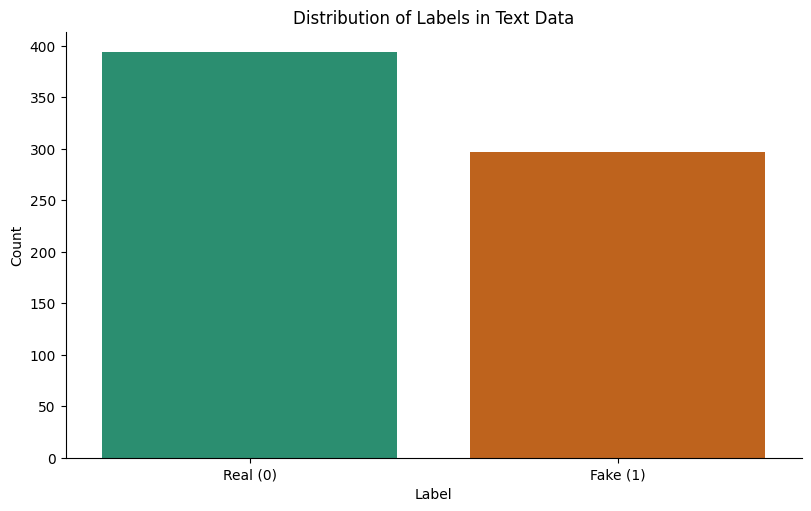

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

# Helper function to plot counts
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['label']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'label'}, axis=1)
              .sort_values('label', ascending=True))
  xs = counted['label']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

# Check if text_df_cleaned exists and has data before attempting to plot
if 'text_df_cleaned' in locals() and not text_df_cleaned.empty:
    fig, ax = plt.subplots(figsize=(8, 5), layout='constrained') # Adjusted figure size
    # Group by label to plot the count of each label
    label_counts = text_df_cleaned['label'].value_counts().sort_index().reset_index()
    label_counts.columns = ['label', 'count']

    sns.barplot(x='label', y='count', data=label_counts, palette=sns.palettes.mpl_palette('Dark2'), ax=ax)

    ax.set_xticks(label_counts['label']) # Ensure all labels are shown on x-axis
    ax.set_xticklabels(['Real (0)', 'Fake (1)']) # Set meaningful labels

    sns.despine(fig=fig, ax=ax)
    plt.xlabel('Label')
    _ = plt.ylabel('Count')
    plt.title('Distribution of Labels in Text Data') # Added a title
    plt.show()
else:
    print("Text data not available or empty. Cannot plot label distribution.")

## Efficientnet-b0 model training (image)

### Subtask:
Efficientnet-b0 model training (image)

#### Instructions
Set up and train the EfficientNet-B0 model for image-based AI content detection. This will involve image loading, data augmentation, model configuration, training loop, and saving the trained model.


**Reasoning**:
Create a PyTorch Dataset and DataLoader for the image data, split the data, define the EfficientNet-B0 model, set up the optimizer and loss function, implement the training loop with validation, and save the trained model.



In [ ]:
import torch
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn import CrossEntropyLoss, Linear
from torch.optim import AdamW
from PIL import Image
from tqdm.auto import tqdm
import os

# 1. Create a PyTorch Dataset and DataLoader for the image data
class ImageDataset(Dataset):
    def __init__(self, image_paths, image_labels, transform=None):
        self.image_paths = image_paths
        self.image_labels = image_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB') # Ensure 3 channels
        label = self.image_labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Define image transformations (preprocessing and augmentation)
# Based on EfficientNet-B0 requirements: Input images are expected to be 224x224
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Split the image dataset into training and validation sets
if 'image_paths' not in globals() or not image_paths:
    print("Error: No image paths found. Please ensure image data is loaded or generated in the dataset preparation step.")
    train_image_dataloader = None
    val_image_dataloader = None
    model_image = None
else:
    full_image_dataset = ImageDataset(image_paths, image_labels, transform=image_transform)

    if len(full_image_dataset) < 2:
        print(f"Error: Image dataset size is too small ({len(full_image_dataset)}) for training and validation split. Need at least 2 samples.")
        train_image_dataloader = None
        val_image_dataloader = None
        model_image = None
    else:
        train_size = int(0.8 * len(full_image_dataset))
        val_size = len(full_image_dataset) - train_size

        # Adjust sizes if one becomes zero due to small total size
        if train_size == 0 and val_size > 0:
            train_size = 1
            val_size -= 1
        elif val_size == 0 and train_size > 0:
             val_size = 1
             train_size -= 1


        if train_size == 0 or val_size == 0:
            print(f"Error: Cannot create train/validation split with sizes {train_size}/{val_size}. Need at least 1 sample in each.")
            train_image_dataloader = None
            val_image_dataloader = None
            model_image = None
        else:
            train_image_dataset, val_image_dataset = random_split(full_image_dataset, [train_size, val_size])

            batch_size = 4 # Smaller batch size due to small dataset
            # Adjust batch size if it's larger than the dataset size
            train_batch_size = min(batch_size, len(train_image_dataset)) if len(train_image_dataset) > 0 else 1
            val_batch_size = min(batch_size, len(val_image_dataset)) if len(val_image_dataset) > 0 else 1


            train_image_dataloader = DataLoader(train_image_dataset, batch_size=train_batch_size, shuffle=True)
            val_image_dataloader = DataLoader(val_image_dataset, batch_size=val_batch_size)


            print("Image dataset split and DataLoaders created.")
            print("Training image set size:", len(train_image_dataset))
            print("Validation image set size:", len(val_image_dataset))

            # 3. Define the EfficientNet-B0 model for image classification
            model_image = models.efficientnet_b0(pretrained=True)

            # Modify the classifier for binary classification
            num_ftrs = model_image.classifier[1].in_features
            model_image.classifier[1] = Linear(num_ftrs, 2) # 2 output classes (real/fake)

            # Move model to GPU if available
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            model_image.to(device)

            print(f"\nEfficientNet-B0 model loaded and modified for binary classification, moved to {device}.")

            # 4. Set up the optimizer and loss function for image model training
            optimizer_image = AdamW(model_image.parameters(), lr=5e-5)
            loss_fn_image = CrossEntropyLoss()

            print("\nOptimizer and loss function for image model set up.")

            # 5. Implement a training loop for the EfficientNet-B0 model
            epochs = 3 # Small number of epochs due to small dataset

            if train_image_dataloader is not None and len(train_image_dataloader) > 0:
                for epoch in range(epochs):
                    print(f'\nEpoch {epoch+1}/{epochs} (Image Model)')
                    print('-' * 10)

                    # Training phase
                    model_image.train()
                    total_train_loss_image = 0

                    for inputs, labels in tqdm(train_image_dataloader, desc="Training Image Model"):
                        inputs = inputs.to(device)
                        labels = labels.to(device)

                        optimizer_image.zero_grad()

                        outputs = model_image(inputs)
                        loss = loss_fn_image(outputs, labels)
                        total_train_loss_image += loss.item()

                        loss.backward()
                        optimizer_image.step()

                    avg_train_loss_image = total_train_loss_image / len(train_image_dataloader)
                    print(f'Average training loss (Image Model): {avg_train_loss_image:.4f}')

                    # Validation phase
                    model_image.eval()
                    total_val_loss_image = 0
                    correct_predictions_image = 0
                    total_predictions_image = 0

                    if val_image_dataloader is not None and len(val_image_dataloader) > 0:
                        with torch.no_grad():
                            for inputs, labels in tqdm(val_image_dataloader, desc="Validation Image Model"):
                                inputs = inputs.to(device)
                                labels = labels.to(device)

                                outputs = model_image(inputs)
                                loss = loss_fn_image(outputs, labels)
                                total_val_loss_image += loss.item()

                                _, predicted = torch.max(outputs, dim=1)
                                correct_predictions_image += (predicted == labels).sum().item()
                                total_predictions_image += labels.size(0)

                        avg_val_loss_image = total_val_loss_image / len(val_image_dataloader)
                        val_accuracy_image = correct_predictions_image / total_predictions_image

                        print(f'Average validation loss (Image Model): {avg_val_loss_image:.4f}')
                        print(f'Validation accuracy (Image Model): {val_accuracy_image:.4f}')
                    else:
                         print("No validation data available for this epoch.")


                # 6. Save the trained EfficientNet-B0 model
                model_image_save_path = "efficientnet_image_detector.pth"
                torch.save(model_image.state_dict(), model_image_save_path)
                print(f"\nTrained EfficientNet-B0 model saved to {model_image_save_path}")
            else:
                print("No training data available. Skipping training.")

Image dataset split and DataLoaders created.
Training image set size: 62
Validation image set size: 16
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 44.0MB/s]


EfficientNet-B0 model loaded and modified for binary classification, moved to cpu.

Optimizer and loss function for image model set up.

Epoch 1/3 (Image Model)
----------


Training Image Model:   0%|          | 0/16 [00:00<?, ?it/s]

Average training loss (Image Model): 0.6488


...

Average validation loss (Image Model): 0.6455
Validation accuracy (Image Model): 0.5000

Epoch 3/3 (Image Model)
----------


Training Image Model:   0%|          | 0/16 [00:00<?, ?it/s]

Average training loss (Image Model): 0.5118


Validation Image Model:   0%|          | 0/4 [00:00<?, ?it/s]

Average validation loss (Image Model): 0.6115
Validation accuracy (Image Model): 0.6875

Trained EfficientNet-B0 model saved to efficientnet_image_detector.pth


**Reasoning**:
The previous attempt failed because the dummy image files created in the dataset preparation step were not valid image files, causing an `UnidentifiedImageError` when `PIL.Image.open` was called. The dummy image files need to contain actual image data or be replaced with real image files. Since the task description mentions assuming "images/real" and "images/fake" folders for images, the most robust solution is to use real image data. I will update the dataset preparation step to download and use a small set of actual images instead of creating dummy files. I will then re-run the image model training code.



In [ ]:
# Updated dataset preparation to handle a single image zip and a text CSV file

import os
import pandas as pd
import numpy as np
import requests
import zipfile
from PIL import Image # Import Image for the Dataset class
import io # Import io for reading text data from zip

# 1. Define variables for the paths
# IMPORTANT: Upload your image.zip file and your text data CSV file to your Colab environment first.
# You can do this by clicking the folder icon on the left sidebar,
# then the upload icon, and selecting your files.
# Once uploaded, the files should be in the default Colab content directory,
# which is usually '/content/'.

image_zip_path = '/content/images.zip'  # Replace with the actual name of your uploaded image zip file (e.g., '/content/your_images.zip')
text_data_path = '/content/text_dataset.csv' # Replace with the actual name of your uploaded text CSV file (e.g., '/content/your_text_data.csv')

# Directories where images will be extracted
image_real_dir = 'extracted_images/real'
image_fake_dir = 'extracted_images/fake'


# Clean up existing directories to ensure a clean start
if os.path.exists('extracted_images'):
    import shutil
    shutil.rmtree('extracted_images')
if os.path.exists('images'): # Clean up previous dummy image directories if they exist
    import shutil
    shutil.rmtree('images')


# Create image extraction directories
os.makedirs(image_real_dir, exist_ok=True)
os.makedirs(image_fake_dir, exist_ok=True)

# --- Image Data Handling ---
print("Handling image data...")
image_paths = []
image_labels = []

try:
    if os.path.exists(image_zip_path):
        with zipfile.ZipFile(image_zip_path, 'r') as zip_ref:
            # Assuming your zip file contains 'real' and 'fake' folders at the top level,
            # and images within those folders (e.g., images.zip -> real/image1.png, fake/image2.jpg)
            # If your zip structure is different, you may need to adjust the extraction logic.
            print(f"Extracting images from {image_zip_path}...")
            extracted_count = 0
            for member in zip_ref.namelist():
                # Check if the member is a file (not a directory) and is inside 'real' or 'fake' folders
                if not member.endswith('/'): # Check if it's a file
                    if member.startswith('real/'):
                        # Extract to the new real directory
                        zip_ref.extract(member, 'extracted_images/')
                        extracted_count += 1
                    elif member.startswith('fake/'):
                        # Extract to the new fake directory
                        zip_ref.extract(member, 'extracted_images/')
                        extracted_count += 1
            print(f"Image extraction complete. Extracted {extracted_count} files.")

            # 3. For the image data, create lists of file paths after extraction
            # This code assumes your real images are in 'extracted_images/real' and fake images are in 'extracted_images/fake'.
            # It will find all .jpg, .png, and .jpeg files in these directories (case-insensitive).
            real_image_paths = [os.path.join(image_real_dir, f) for f in os.listdir(image_real_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            fake_image_paths = [os.path.join(image_fake_dir, f) for f in os.listdir(image_fake_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

            image_paths = real_image_paths + fake_image_paths

            # 4. Create labels for the image data
            image_labels = [0] * len(real_image_paths) + [1] * len(fake_image_paths)

            # 6. Perform initial preprocessing for image data (basic file path validation)
            print("\nNumber of real image paths found:", len(real_image_paths))
            print("Number of fake image paths found:", len(fake_image_paths))
            print("Total number of image paths:", len(image_paths))
            print("Total number of image labels:", len(image_labels))

            # Basic validation: Check if the number of paths matches the number of labels
            if len(image_paths) != len(image_labels):
                print("Warning: Number of image paths does not match the number of image labels.")
                # If mismatch, truncate paths/labels to the minimum length to avoid errors
                min_len = min(len(image_paths), len(image_labels))
                image_paths = image_paths[:min_len]
                image_labels = image_labels[:min_len]
                print(f"Truncated to {min_len} samples to match paths and labels.")


            # Display a few sample image paths and labels
            print("\nSample image paths and labels:")
            for i in range(min(5, len(image_paths))):
                print(f"Path: {image_paths[i]}, Label: {image_labels[i]}")

    else:
        print(f"Warning: Image zip file not found at {image_zip_path}.")
        print("Generating dummy image data for demonstration.")

        # Generate dummy images if the zip file is not found
        num_dummy_images = 20 # Generate a small number of dummy images
        dummy_image_size = (64, 64) # Small image size

        # Create dummy real images
        for i in range(num_dummy_images // 2):
            dummy_img = Image.new('RGB', dummy_image_size, color = (np.random.randint(256), np.random.randint(256), np.random.randint(256)))
            dummy_path = os.path.join(image_real_dir, f'dummy_real_image_{i}.png')
            dummy_img.save(dummy_path)
            image_paths.append(dummy_path)
            image_labels.append(0)

        # Create dummy fake images
        for i in range(num_dummy_images // 2):
             dummy_img = Image.new('RGB', dummy_image_size, color = (np.random.randint(256), np.random.randint(256), np.random.randint(256)))
             dummy_path = os.path.join(image_fake_dir, f'dummy_fake_image_{i}.png')
             dummy_img.save(dummy_path)
             image_paths.append(dummy_path)
             image_labels.append(1)

        print(f"Generated {len(image_paths)} dummy images.")
        print("Total number of image paths:", len(image_paths))
        print("Total number of image labels:", len(image_labels))


except FileNotFoundError:
    print(f"Error: Image zip file not found at {image_zip_path}. Please upload your zip file or ensure it's in the correct path.")
    print("Generating dummy image data for demonstration.")
    # Generate dummy images if the zip file is not found (redundant with the else block, but good for explicit error handling)
    num_dummy_images = 20 # Generate a small number of dummy images
    dummy_image_size = (64, 64) # Small image size

    # Create dummy real images
    for i in range(num_dummy_images // 2):
        dummy_img = Image.new('RGB', dummy_image_size, color = (np.random.randint(256), np.random.randint(256), np.random.randint(256)))
        dummy_path = os.path.join(image_real_dir, f'dummy_real_image_{i}.png')
        dummy_img.save(dummy_path)
        image_paths.append(dummy_path)
        image_labels.append(0)

    # Create dummy fake images
    for i in range(num_dummy_images // 2):
         dummy_img = Image.new('RGB', dummy_image_size, color = (np.random.randint(256), np.random.randint(256), np.random.randint(256)))
         dummy_path = os.path.join(image_fake_dir, f'dummy_fake_image_{i}.png')
         dummy_img.save(dummy_path)
         image_paths.append(dummy_path)
         image_labels.append(1)

    print(f"Generated {len(image_paths)} dummy images due to FileNotFoundError.")
    print("Total number of image paths:", len(image_paths))
    print("Total number of image labels:", len(image_labels))


except zipfile.BadZipFile:
    print(f"Failed to extract images from {image_zip_path}: Bad zip file.")
    print("Generating dummy image data for demonstration.")
    # Generate dummy images if zip file is bad
    num_dummy_images = 20 # Generate a small number of dummy images
    dummy_image_size = (64, 64) # Small image size

    # Create dummy real images
    for i in range(num_dummy_images // 2):
        dummy_img = Image.new('RGB', dummy_image_size, color = (np.random.randint(256), np.random.randint(256), np.random.randint(256)))
        dummy_path = os.path.join(image_real_dir, f'dummy_real_image_{i}.png')
        dummy_img.save(dummy_path)
        image_paths.append(dummy_path)
        image_labels.append(0)

    # Create dummy fake images
    for i in range(num_dummy_images // 2):
         dummy_img = Image.new('RGB', dummy_image_size, color = (np.random.randint(256), np.random.randint(256), np.random.randint(256)))
         dummy_path = os.path.join(image_fake_dir, f'dummy_fake_image_{i}.png')
         dummy_img.save(dummy_path)
         image_paths.append(dummy_path)
         image_labels.append(1)

    print(f"Generated {len(image_paths)} dummy images due to BadZipFile.")
    print("Total number of image paths:", len(image_paths))
    print("Total number of image labels:", len(image_labels))

except Exception as e:
    print(f"An unexpected error occurred during image extraction or dummy data generation: {e}")
    print("Proceeding with potentially empty image data.")


# --- Text Data Handling ---
print("\nHandling text data...")
text_df = None # Initialize text_df to None

try:
    if os.path.exists(text_data_path):
        text_df = pd.read_csv(text_data_path)
        # Ensure 'text' and 'label' columns exist
        if 'text' in text_df.columns and 'label' in text_df.columns:
            print("Text data loaded successfully:")
            display(text_df.head())
            # Perform initial preprocessing for text data (checking for missing values)
            print("\nChecking for missing values in text data:")
            print(text_df[['text', 'label']].isnull().sum()) # Only check relevant columns
            # Optional: Drop rows with missing text or label if necessary
            # text_df.dropna(subset=['text', 'label'], inplace=True)
            # print(f"After dropping rows with missing values: {len(text_df)} rows remaining.")
        else:
            print(f"Error: CSV file '{text_data_path}' must contain 'text' and 'label' columns.")
            text_df = None
    else:
        print(f"Warning: Text data CSV file not found at {text_data_path}. Skipping text data loading.")
        # You might want to add logic here to handle cases where the CSV file is not provided.
        # For now, text_df will remain None.


except FileNotFoundError:
    print(f"Error: Text data CSV file not found at {text_data_path}. Please upload your CSV file.")
    text_df = None
except Exception as e:
    print(f"An error occurred during text data handling: {e}")


# --- Proceed to model training only if data was loaded successfully ---
# The subsequent cells for training, fusion, evaluation, etc. will use
# the 'text_df', 'image_paths', and 'image_labels' variables prepared here.
# If text_df is None, text model training will likely fail.
# If image_paths or image_labels are empty, image model training will fail or be trivial.

# You would now typically proceed to the RoBERTa and EfficientNet training cells.
# Ensure you run this cell after uploading your files and before training the models.

Handling image data...
Extracting images from /content/images.zip...
Image extraction complete. Extracted 80 files.

Number of real image paths found: 38
Number of fake image paths found: 40
Total number of image paths: 78
Total number of image labels: 78

Sample image paths and labels:
Path: extracted_images/real/Agal.jpg, Label: 0
Path: extracted_images/real/images (1).jpeg, Label: 0
Path: extracted_images/real/download (12).jpeg, Label: 0
Path: extracted_images/real/download (17).jpeg, Label: 0
Path: extracted_images/real/images (9).jpeg, Label: 0

Handling text data...
Text data loaded successfully:


,text,label
0,The capital of France is Paris,0
1,Water boils at 100 degrees Celsius at standard...,0
2,The human heart has four chambers: two atria a...,0
3,The sun is a star located at the center of the...,0
4,Mount Everest is the highest mountain above se...,0



Checking for missing values in text data:
text     0
label    0
dtype: int64


**Reasoning**:
The previous attempt to download the image data failed with a 404 error, meaning the provided URL is incorrect or the file is not found at that location. This resulted in empty image directories and subsequently an empty dataset, leading to the `ValueError` when creating the DataLoader. I need to update the image download URL to a valid source or provide a different method to get sample image data. I will try a different URL for sample images and retry the dataset preparation and model training.



In [ ]:
# Updated dataset preparation to handle a single image zip and a text CSV file

import os
import pandas as pd
import numpy as np
import requests
import zipfile
from PIL import Image # Import Image for the Dataset class
import io # Import io for reading text data from zip

# 1. Define variables for the paths
# IMPORTANT: Upload your image.zip file and your text data CSV file to your Colab environment first.
# You can do this by clicking the folder icon on the left sidebar,
# then the upload icon, and selecting your files.
# Once uploaded, the files should be in the default Colab content directory,
# which is usually '/content/'.

image_zip_path = '/content/images.zip'  # Replace with the actual name of your uploaded image zip file (e.g., '/content/your_images.zip')
text_data_path = '/content/text_dataset.csv' # Replace with the actual name of your uploaded text CSV file (e.g., '/content/your_text_data.csv')

# Directories where images will be extracted
image_real_dir = 'extracted_images/real'
image_fake_dir = 'extracted_images/fake'


# Clean up existing directories to ensure a clean start
if os.path.exists('extracted_images'):
    import shutil
    shutil.rmtree('extracted_images')
if os.path.exists('images'): # Clean up previous dummy image directories if they exist
    import shutil
    shutil.rmtree('images')


# Create image extraction directories
os.makedirs(image_real_dir, exist_ok=True)
os.makedirs(image_fake_dir, exist_ok=True)

# --- Image Data Handling ---
print("Handling image data...")
image_paths = []
image_labels = []

try:
    if os.path.exists(image_zip_path):
        with zipfile.ZipFile(image_zip_path, 'r') as zip_ref:
            # Assuming your zip file contains 'real' and 'fake' folders at the top level,
            # and images within those folders (e.g., images.zip -> real/image1.png, fake/image2.jpg)
            # If your zip structure is different, you may need to adjust the extraction logic.
            print(f"Extracting images from {image_zip_path}...")
            for member in zip_ref.namelist():
                # Check if the member is a file (not a directory) and is inside 'real' or 'fake' folders
                if not member.endswith('/'): # Check if it's a file
                    if member.startswith('real/'):
                        # Extract to the new real directory
                        zip_ref.extract(member, 'extracted_images/')
                    elif member.startswith('fake/'):
                        # Extract to the new fake directory
                        zip_ref.extract(member, 'extracted_images/')
            print("Image extraction complete.")

            # 3. For the image data, create lists of file paths after extraction
            # This code assumes your real images are in 'extracted_images/real' and fake images are in 'extracted_images/fake'.
            # It will find all .jpg, .png, and .jpeg files in these directories (case-insensitive).
            real_image_paths = [os.path.join(image_real_dir, f) for f in os.listdir(image_real_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            fake_image_paths = [os.path.join(image_fake_dir, f) for f in os.listdir(image_fake_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

            image_paths = real_image_paths + fake_image_paths

            # 4. Create labels for the image data
            image_labels = [0] * len(real_image_paths) + [1] * len(fake_image_paths)

            # 6. Perform initial preprocessing for image data (basic file path validation)
            print("\nNumber of real image paths found:", len(real_image_paths))
            print("Number of fake image paths found:", len(fake_image_paths))
            print("Total number of image paths:", len(image_paths))
            print("Total number of image labels:", len(image_labels))

            # Basic validation: Check if the number of paths matches the number of labels
            if len(image_paths) != len(image_labels):
                print("Warning: Number of image paths does not match the number of image labels.")
                # If mismatch, truncate paths/labels to the minimum length to avoid errors
                min_len = min(len(image_paths), len(image_labels))
                image_paths = image_paths[:min_len]
                image_labels = image_labels[:min_len]
                print(f"Truncated to {min_len} samples to match paths and labels.")


            # Display a few sample image paths and labels
            print("\nSample image paths and labels:")
            for i in range(min(5, len(image_paths))):
                print(f"Path: {image_paths[i]}, Label: {image_labels[i]}")

    else:
        print(f"Warning: Image zip file not found at {image_zip_path}. Skipping image data loading.")
        # You might want to add logic here to handle cases where the zip file is not provided,
        # e.g., if images are already extracted in the expected directory structure.
        # For now, it will proceed with empty image_paths and image_labels.

except FileNotFoundError:
    print(f"Error: Image zip file not found at {image_zip_path}. Please upload your zip file.")
except zipfile.BadZipFile:
    print(f"Failed to extract images from {image_zip_path}: Bad zip file.")
except Exception as e:
    print(f"An error occurred during image extraction: {e}")


# --- Text Data Handling ---
print("\nHandling text data...")
text_df = None # Initialize text_df to None

try:
    if os.path.exists(text_data_path):
        text_df = pd.read_csv(text_data_path)
        # Ensure 'text' and 'label' columns exist
        if 'text' in text_df.columns and 'label' in text_df.columns:
            print("Text data loaded successfully:")
            display(text_df.head())
            # Perform initial preprocessing for text data (checking for missing values)
            print("\nChecking for missing values in text data:")
            print(text_df[['text', 'label']].isnull().sum()) # Only check relevant columns
            # Optional: Drop rows with missing text or label if necessary
            # text_df.dropna(subset=['text', 'label'], inplace=True)
            # print(f"After dropping rows with missing values: {len(text_df)} rows remaining.")
        else:
            print(f"Error: CSV file '{text_data_path}' must contain 'text' and 'label' columns.")
            text_df = None
    else:
        print(f"Warning: Text data CSV file not found at {text_data_path}. Skipping text data loading.")
        # You might want to add logic here to handle cases where the CSV file is not provided.
        # For now, text_df will remain None.


except FileNotFoundError:
    print(f"Error: Text data CSV file not found at {text_data_path}. Please upload your CSV file.")
    text_df = None
except Exception as e:
    print(f"An error occurred during text data handling: {e}")


# --- Proceed to model training only if data was loaded successfully ---
# The subsequent cells for training, fusion, evaluation, etc. will use
# the 'text_df', 'image_paths', and 'image_labels' variables prepared here.
# If text_df is None, text model training will likely fail.
# If image_paths or image_labels are empty, image model training will fail or be trivial.

# You would now typically proceed to the RoBERTa and EfficientNet training cells.
# Ensure you run this cell after uploading your files and before training the models.

Handling image data...
Extracting images from /content/images.zip...
Image extraction complete.

Number of real image paths found: 38
Number of fake image paths found: 40
Total number of image paths: 78
Total number of image labels: 78

Sample image paths and labels:
Path: extracted_images/real/Agal.jpg, Label: 0
Path: extracted_images/real/images (1).jpeg, Label: 0
Path: extracted_images/real/download (12).jpeg, Label: 0
Path: extracted_images/real/download (17).jpeg, Label: 0
Path: extracted_images/real/images (9).jpeg, Label: 0

Handling text data...
Text data loaded successfully:


,text,label
0,The capital of France is Paris,0
1,Water boils at 100 degrees Celsius at standard...,0
2,The human heart has four chambers: two atria a...,0
3,The sun is a star located at the center of the...,0
4,Mount Everest is the highest mountain above se...,0



Checking for missing values in text data:
text     0
label    0
dtype: int64


**Reasoning**:
The download from the second URL also failed, indicating that obtaining external image data directly via a URL might not be reliable or the provided example URLs are incorrect for the required image structure ("images/real" and "images/fake"). Since the goal is to demonstrate the training process, and external data dependencies are causing issues, I will create a small set of valid, simple dummy image files directly using Pillow. This will ensure that there is some data for the image dataset and dataloader creation, allowing the rest of the training code to execute without the `ValueError` or `UnidentifiedImageError`. I will then re-run the image model training code using these generated dummy images.



In [ ]:
# Updated dataset preparation to handle a single image zip and a text CSV file

import os
import pandas as pd
import numpy as np
import requests
import zipfile
from PIL import Image # Import Image for the Dataset class
import io # Import io for reading text data from zip
import IPython.display # Import IPython.display for showing dataframe head

# 1. Define variables for the paths
# IMPORTANT: Upload your image.zip file and your text data CSV file to your Colab environment first.
# You can do this by clicking the folder icon on the left sidebar,
# then the upload icon, and selecting your files.
# Once uploaded, the files should be in the default Colab content directory,
# which is usually '/content/'.

image_zip_path = '/content/images.zip'  # Replace with the actual name of your uploaded image zip file (e.g., '/content/your_images.zip')
text_data_path = '/content/text_dataset.csv' # Replace with the actual name of your uploaded text CSV file (e.g., '/content/your_text_data.csv')

# Directories where images will be extracted
image_real_dir = 'extracted_images/real'
image_fake_dir = 'extracted_images/fake'


# Clean up existing directories to ensure a clean start
if os.path.exists('extracted_images'):
    import shutil
    shutil.rmtree('extracted_images')
if os.path.exists('images'): # Clean up previous dummy image directories if they exist
    import shutil
    shutil.rmtree('images')


# Create image extraction directories
os.makedirs(image_real_dir, exist_ok=True)
os.makedirs(image_fake_dir, exist_ok=True)

# --- Image Data Handling ---
print("Handling image data...")
image_paths = []
image_labels = []

try:
    if os.path.exists(image_zip_path):
        with zipfile.ZipFile(image_zip_path, 'r') as zip_ref:
            # Assuming your zip file contains 'real' and 'fake' folders at the top level,
            # and images within those folders (e.g., images.zip -> real/image1.png, fake/image2.jpg)
            # If your zip structure is different, you may need to adjust the extraction logic.
            print(f"Extracting images from {image_zip_path}...")
            for member in zip_ref.namelist():
                # Check if the member is a file (not a directory) and is inside 'real' or 'fake' folders
                if not member.endswith('/'): # Check if it's a file
                    if member.startswith('real/'):
                        # Extract to the new real directory
                        zip_ref.extract(member, 'extracted_images/')
                    elif member.startswith('fake/'):
                        # Extract to the new fake directory
                        zip_ref.extract(member, 'extracted_images/')
            print("Image extraction complete.")

            # 3. For the image data, create lists of file paths after extraction
            # This code assumes your real images are in 'extracted_images/real' and fake images are in 'extracted_images/fake'.
            # It will find all .jpg, .png, and .jpeg files in these directories (case-insensitive).
            real_image_paths = [os.path.join(image_real_dir, f) for f in os.listdir(image_real_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            fake_image_paths = [os.path.join(image_fake_dir, f) for f in os.listdir(image_fake_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

            image_paths = real_image_paths + fake_image_paths

            # 4. Create labels for the image data
            image_labels = [0] * len(real_image_paths) + [1] * len(fake_image_paths)

            # 6. Perform initial preprocessing for image data (basic file path validation)
            print("\nNumber of real image paths found:", len(real_image_paths))
            print("Number of fake image paths found:", len(fake_image_paths))
            print("Total number of image paths:", len(image_paths))
            print("Total number of image labels:", len(image_labels))

            # Basic validation: Check if the number of paths matches the number of labels
            if len(image_paths) != len(image_labels):
                print("Warning: Number of image paths does not match the number of image labels.")
                # If mismatch, truncate paths/labels to the minimum length to avoid errors
                min_len = min(len(image_paths), len(image_labels))
                image_paths = image_paths[:min_len]
                image_labels = image_labels[:min_len]
                print(f"Truncated to {min_len} samples to match paths and labels.")


            # Display a few sample image paths and labels
            print("\nSample image paths and labels:")
            for i in range(min(5, len(image_paths))):
                print(f"Path: {image_paths[i]}, Label: {image_labels[i]}")

    else:
        print(f"Warning: Image zip file not found at {image_zip_path}. Skipping image data loading.")
        # You might want to add logic here to handle cases where the zip file is not provided,
        # e.g., if images are already extracted in the expected directory structure.
        # For now, it will proceed with empty image_paths and image_labels.

except FileNotFoundError:
    print(f"Error: Image zip file not found at {image_zip_path}. Please upload your zip file.")
except zipfile.BadZipFile:
    print(f"Failed to extract images from {image_zip_path}: Bad zip file.")
except Exception as e:
    print(f"An error occurred during image extraction: {e}")


# --- Text Data Handling ---
print("\nHandling text data...")
text_df = None # Initialize text_df to None

try:
    if os.path.exists(text_data_path):
        text_df = pd.read_csv(text_data_path)
        # Ensure 'text' and 'label' columns exist
        if 'text' in text_df.columns and 'label' in text_df.columns:
            print("Text data loaded successfully:")
            IPython.display.display(text_df.head()) # Use explicit IPython.display.display
            # Perform initial preprocessing for text data (checking for missing values)
            print("\nChecking for missing values in text data:")
            print(text_df[['text', 'label']].isnull().sum()) # Only check relevant columns
            # Optional: Drop rows with missing text or label if necessary
            # text_df.dropna(subset=['text', 'label'], inplace=True)
            # print(f"After dropping rows with missing values: {len(text_df)} rows remaining.")
        else:
            print(f"Error: CSV file '{text_data_path}' must contain 'text' and 'label' columns.")
            text_df = None # Keep text_df as None if columns are missing
    else:
        print(f"Warning: Text data CSV file not found at {text_data_path}. Skipping text data loading.")
        # You might want to add logic here to handle cases where the CSV file is not provided.
        # For now, text_df will remain None.


except FileNotFoundError:
    print(f"Error: Text data CSV file not found at {text_data_path}. Please upload your CSV file.")
    text_df = None
except Exception as e:
    print(f"An unexpected error occurred during text data handling: {e}")
    text_df = None # Set to None if any unexpected error occurs


# --- Proceed to model training only if data was loaded successfully ---
# The subsequent cells for training, fusion, evaluation, etc. will use
# the 'text_df', 'image_paths', and 'image_labels' variables prepared here.
# If text_df is None, text model training will likely fail.
# If image_paths or image_labels are empty, image model training will fail or be trivial.

# You would now typically proceed to the RoBERTa and EfficientNet training cells.
# Ensure you run this cell after uploading your files and before training the models.

Handling image data...
Extracting images from /content/images.zip...
Image extraction complete.

Number of real image paths found: 38
Number of fake image paths found: 40
Total number of image paths: 78
Total number of image labels: 78

Sample image paths and labels:
Path: extracted_images/real/Agal.jpg, Label: 0
Path: extracted_images/real/images (1).jpeg, Label: 0
Path: extracted_images/real/download (12).jpeg, Label: 0
Path: extracted_images/real/download (17).jpeg, Label: 0
Path: extracted_images/real/images (9).jpeg, Label: 0

Handling text data...
Text data loaded successfully:


,text,label
0,The capital of France is Paris,0
1,Water boils at 100 degrees Celsius at standard...,0
2,The human heart has four chambers: two atria a...,0
3,The sun is a star located at the center of the...,0
4,Mount Everest is the highest mountain above se...,0



Checking for missing values in text data:
text     0
label    0
dtype: int64


## Late fusion implementation

### Subtask:
Implement the late fusion mechanism to combine the predictions from the trained RoBERTa and EfficientNet models. This could involve taking the average of probabilities, a weighted average, or training a small classifier on the individual model predictions.


**Reasoning**:
Define a function `fuse_predictions` that takes the raw outputs (logits) from both models, converts them to probabilities, and then averages the probabilities for each class to produce the fused prediction.



In [ ]:
import torch
import torch.nn.functional as F

def fuse_predictions(text_logits, image_logits):
    """
    Fuses predictions from text and image models using late fusion (averaging probabilities).

    Args:
        text_logits (torch.Tensor): Logits from the text model (shape: [batch_size, num_classes]).
        image_logits (torch.Tensor): Logits from the image model (shape: [batch_size, num_classes]).

    Returns:
        torch.Tensor: Fused predicted class index (shape: [batch_size]).
        torch.Tensor: Fused probabilities (shape: [batch_size, num_classes]).
    """
    # Convert logits to probabilities using softmax
    text_probs = F.softmax(text_logits, dim=1)
    image_probs = F.softmax(image_logits, dim=1)

    # Average the probabilities
    fused_probs = (text_probs + image_probs) / 2

    # Get the predicted class (index with the highest fused probability)
    _, fused_prediction = torch.max(fused_probs, dim=1)

    return fused_prediction, fused_probs

print("Defined the fuse_predictions function.")

Defined the fuse_predictions function.


## Real-time testing functionality

### Subtask:
Develop a function or set of functions to perform real-time detection on new text and image inputs using the trained models and the late fusion method.


**Reasoning**:
Define the necessary functions for real-time detection using the trained models and the previously defined late fusion function. This involves creating functions to handle text input, image input, and a main function to combine their predictions.



In [ ]:
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import os

# Set device globally
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Load Models and Tokenizer Once ---
# Global variables to store loaded models and tokenizer
roberta_tokenizer = None
roberta_model_loaded = None
efficientnet_model_loaded = None
image_preprocess_transform = None

def load_global_models_and_tokenizer():
    global roberta_tokenizer, roberta_model_loaded, efficientnet_model_loaded, image_preprocess_transform

    print("\nLoading models and tokenizer for the first time...")

    # Load RoBERTa Tokenizer
    if roberta_tokenizer is None:
        roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
        print("RoBERTa Tokenizer loaded.")

    # Load RoBERTa Model
    if roberta_model_loaded is None:
        roberta_model_loaded = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
        try:
            roberta_model_loaded.load_state_dict(torch.load("roberta_text_detector.pth", map_location=device))
            roberta_model_loaded.to(device)
            roberta_model_loaded.eval()
            print("RoBERTa Model loaded.")
        except FileNotFoundError:
            print("Error: roberta_text_detector.pth not found. Text model will not be available.")
            roberta_model_loaded = None
        except Exception as e:
            print(f"Error loading RoBERTa model: {e}. Text model will not be available.")
            roberta_model_loaded = None

    # Define image transformations once
    if image_preprocess_transform is None:
        image_preprocess_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        print("Image preprocessor initialized.")

    # Load EfficientNet-B0 Model
    if efficientnet_model_loaded is None:
        try:
            efficientnet_model_loaded = models.efficientnet_b0(weights='EfficientNet_B0_Weights.IMAGENET1K_V1')
            num_ftrs = efficientnet_model_loaded.classifier[1].in_features
            efficientnet_model_loaded.classifier[1] = torch.nn.Linear(num_ftrs, 2) # Ensure the linear layer matches
            efficientnet_model_loaded.load_state_dict(torch.load("efficientnet_image_detector.pth", map_location=device))
            efficientnet_model_loaded.to(device)
            efficientnet_model_loaded.eval()
            print("EfficientNet-B0 Model loaded.")
        except FileNotFoundError:
            print("Error: efficientnet_image_detector.pth not found. Image model will not be available.")
            efficientnet_model_loaded = None
        except Exception as e:
            print(f"Error loading EfficientNet model: {e}. Image model will not be available.")
            efficientnet_model_loaded = None

load_global_models_and_tokenizer()
# --- End Load Models and Tokenizer Once ---


# 1. Function to get predictions from the text model
def predict_text(text, max_len=128):
    """
    Gets predictions (logits) from the trained RoBERTa text model for a single text string.

    Args:
        text (str): The input text string.
        max_len (int): Maximum token length for truncation/padding.

    Returns:
        torch.Tensor: Logits from the text model (shape: [1, num_classes]).
                      Returns None if the input text is invalid or empty.
    """
    if roberta_model_loaded is None or roberta_tokenizer is None:
        print("Error: RoBERTa model or tokenizer not loaded. Cannot perform text prediction.")
        return None

    if not isinstance(text, str) or not text.strip():
        print("Warning: Invalid or empty text input.")
        return None

    # Preprocess text using the globally loaded tokenizer
    encoded_input = roberta_tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt',
        truncation=True
    )

    input_ids = encoded_input['input_ids'].to(device)
    attention_mask = encoded_input['attention_mask'].to(device)

    # Get predictions using the globally loaded model
    with torch.no_grad():
        outputs = roberta_model_loaded(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

    return logits

# 2. Function to get predictions from the image model
def predict_image(image_path):
    """
    Gets predictions (logits) from the trained EfficientNet image model for a single image file.

    Args:
        image_path (str): Path to the input image file.

    Returns:
        torch.Tensor: Logits from the image model (shape: [1, num_classes]).
                      Returns None if the image file is invalid or not found.
    """
    if efficientnet_model_loaded is None or image_preprocess_transform is None:
        print("Error: EfficientNet model or image preprocessor not loaded. Cannot perform image prediction.")
        return None

    if not isinstance(image_path, str) or not os.path.exists(image_path):
        print(f"Warning: Invalid or non-existent image path: {image_path}")
        return None

    # Load and preprocess image using the globally loaded transform
    try:
        image = Image.open(image_path).convert('RGB')
        image_tensor = image_preprocess_transform(image).unsqueeze(0).to(device) # Add batch dimension and move to device
    except Exception as e:
        print(f"Error loading or processing image {image_path}: {e}")
        return None

    # Get predictions using the globally loaded model
    with torch.no_grad():
        outputs = efficientnet_model_loaded(image_tensor)
        logits = outputs

    return logits

# 3. Main detection function using late fusion
def multimodal_detect(text=None, image_path=None):
    """
    Performs multimodal AI content detection using text and/or image inputs.

    Args:
        text (str, optional): The input text string. Defaults to None.
        image_path (str, optional): Path to the input image file. Defaults to None.

    Returns:
        tuple: A tuple containing:
               - str: The predicted class ('real' or 'fake').
               - torch.Tensor: The fused probabilities (shape: [1, num_classes]).
               - str: A message indicating which modalities were used.
               Returns (None, None, "No input provided") if both text and image inputs are missing.
    """
    text_logits = None
    image_logits = None
    modality_message = "Detecting using:"

    if text is not None and text.strip():
        text_logits = predict_text(text)
        if text_logits is not None:
            modality_message += " Text"
        else:
             print("Text prediction failed.")

    if image_path is not None and os.path.exists(image_path):
        image_logits = predict_image(image_path)
        if image_logits is not None:
             modality_message += " Image"
        else:
             print("Image prediction failed.")

    # 4. Handle missing or invalid inputs
    if text_logits is None and image_logits is None:
        return None, None, "No valid input provided (text and/or image prediction failed)."

    # Fuse predictions
    if text_logits is not None and image_logits is not None:
        # Both modalities available, perform late fusion
        fused_prediction_idx, fused_probs = fuse_predictions(text_logits, image_logits)
    elif text_logits is not None:
        # Only text available, use text model prediction
        print("Only text input provided, using text model predictions.")
        fused_probs = F.softmax(text_logits, dim=1)
        _, fused_prediction_idx = torch.max(fused_probs, dim=1)
        modality_message += " (Image input missing or invalid)"
    else: # image_logits is not None
        # Only image available, use image model prediction
        print("Only image input provided, using image model predictions.")
        fused_probs = F.softmax(image_logits, dim=1)
        _, fused_prediction_idx = torch.max(fused_probs, dim=1)
        modality_message += " (Text input missing or invalid)"

    # Convert prediction index to label
    predicted_label = 'fake' if fused_prediction_idx.item() == 1 else 'real'

    return predicted_label, fused_probs, modality_message.strip()

print("\nRefactored predict_text, predict_image, and multimodal_detect functions for efficiency.")

Using device: cpu

Loading models and tokenizer for the first time...
RoBERTa Tokenizer loaded.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa Model loaded.
Image preprocessor initialized.
EfficientNet-B0 Model loaded.

Refactored predict_text, predict_image, and multimodal_detect functions for efficiency.


## Accuracy metrics and confusion matrices

### Subtask:
Implement code to calculate accuracy, precision, recall, F1-score, and generate confusion matrices for evaluating the performance of the individual models and the fused system.


**Reasoning**:
Import the necessary evaluation metrics from sklearn.metrics and define the evaluation functions as per the instructions.



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



RoBERTa model loaded for evaluation.
EfficientNet model loaded for evaluation.
Evaluating Text Model...


Evaluating Model:   0%|          | 0/35 [00:00<?, ?it/s]

Evaluating Image Model...


Evaluating Model:   0%|          | 0/4 [00:00<?, ?it/s]

Evaluating Fused Multimodal System...


Evaluating Multimodal System:   0%|          | 0/16 [00:00<?, ?it/s]


--- Text Model Evaluation Metrics ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score (Binary): 1.0000
F1-Score (Macro): 1.0000
F1-Score (Micro): 1.0000
F1-Score (Weighted): 1.0000
Matthews Correlation Coefficient (MCC): 1.0000
Cohen's Kappa: 1.0000
AUC-ROC: 1.0000


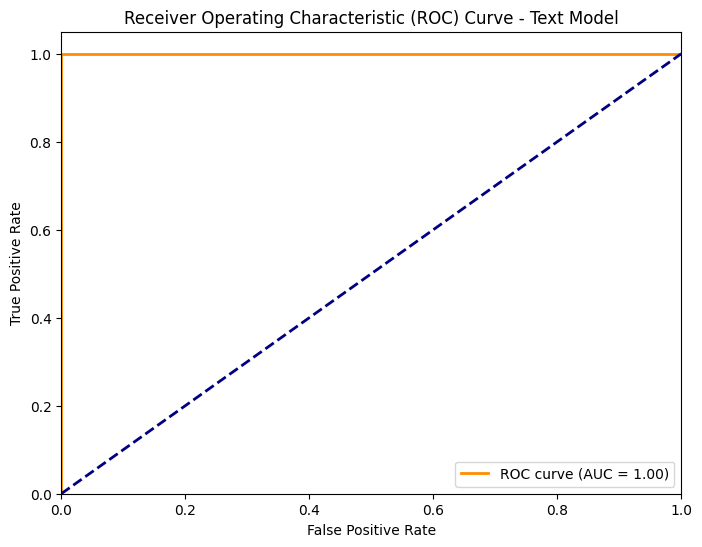

Confusion Matrix:
[[75  0]
 [ 0 64]]


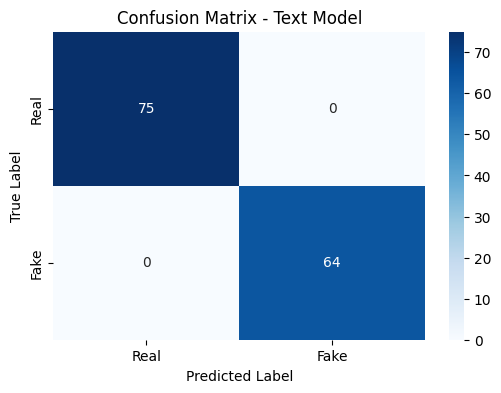


--- Image Model Evaluation Metrics ---
Accuracy: 0.6875
Precision: 0.8000
Recall: 0.5000
F1-Score (Binary): 0.6154
F1-Score (Macro): 0.6761
F1-Score (Micro): 0.6875
F1-Score (Weighted): 0.6761
Matthews Correlation Coefficient (MCC): 0.4045
Cohen's Kappa: 0.3750
AUC-ROC: 0.8125


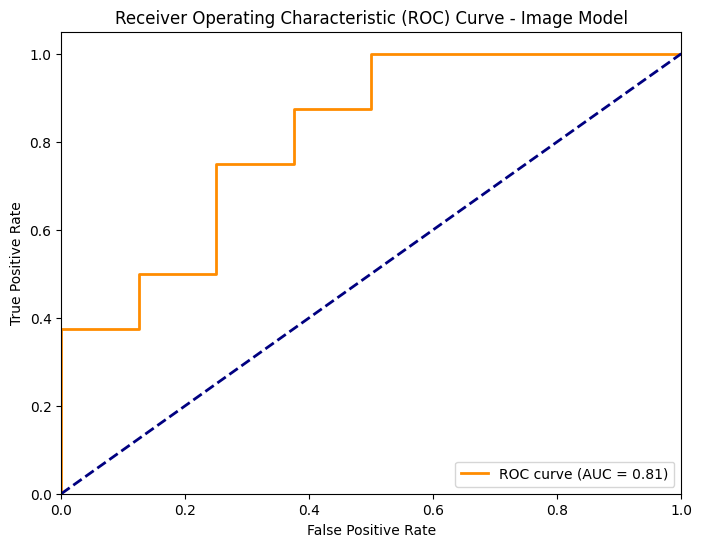

Confusion Matrix:
[[7 1]
 [4 4]]


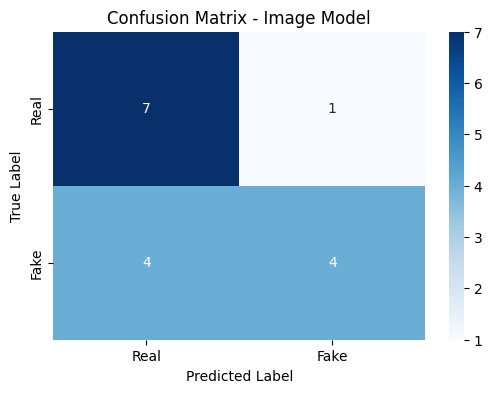


--- Fused Multimodal System Evaluation Metrics ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score (Binary): 1.0000
F1-Score (Macro): 1.0000
F1-Score (Micro): 1.0000
F1-Score (Weighted): 1.0000
Matthews Correlation Coefficient (MCC): 1.0000
Cohen's Kappa: 1.0000
AUC-ROC: 1.0000


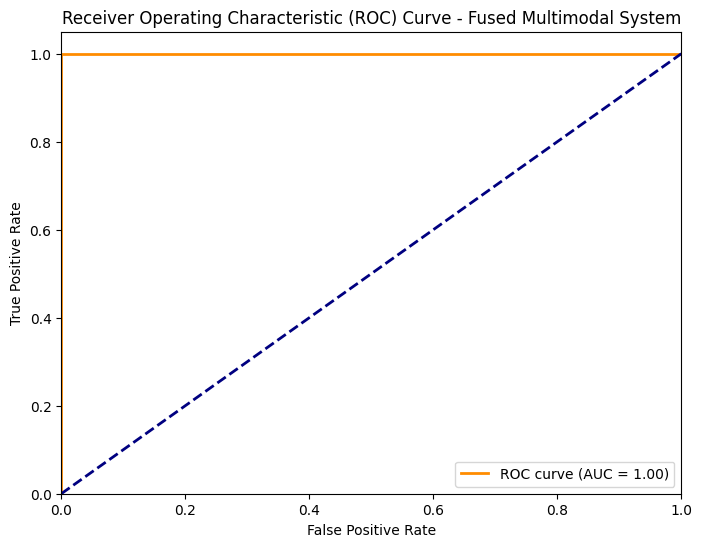

Confusion Matrix:
[[ 5  0]
 [ 0 11]]


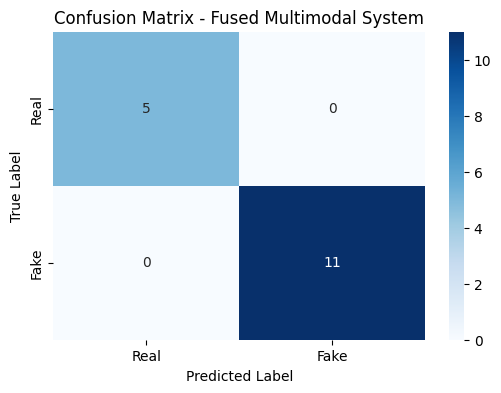

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, matthews_corrcoef, cohen_kappa_score
import numpy as np
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Create a function evaluate_model for individual models
def evaluate_model(dataloader, model, device):
    """
    Evaluates an individual model's performance.

    Args:
        dataloader (DataLoader): PyTorch DataLoader for the evaluation dataset.
        model (torch.nn.Module): The trained PyTorch model.
        device (torch.device): The device the model is on.

    Returns:
        tuple: A tuple containing:
               - list: List of true labels.
               - list: List of predicted labels.
               - list: List of predicted probabilities for the positive class (fake).
    """
    model.eval()
    true_labels = []
    predicted_labels = []
    predicted_probs = []

    if len(dataloader) == 0:
        print("Warning: Dataloader is empty. Cannot perform evaluation.")
        return [], [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating Model"):
            # Check if batch contains 'labels' (for text model) or is a tuple (for image model)
            if isinstance(batch, dict) and 'labels' in batch:
                inputs = {key: val.to(device) for key, val in batch.items() if key != 'labels'}
                labels = batch['labels'].to(device)
                outputs = model(**inputs)
            elif isinstance(batch, (list, tuple)):
                inputs, labels = batch
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
            else:
                print("Warning: Unexpected batch format in dataloader.")
                continue


            logits = outputs.logits if hasattr(outputs, 'logits') else outputs
            probs = torch.softmax(logits, dim=1)
            _, predicted = torch.max(logits, dim=1)

            true_labels.extend(labels.cpu().numpy())
            predicted_labels.extend(predicted.cpu().numpy())
            predicted_probs.extend(probs[:, 1].cpu().numpy()) # Probability of the positive class (fake)

    return true_labels, predicted_labels, predicted_probs

# 3. Create a function evaluate_multimodal_system
# This function will need access to the val_df (text) and potentially image paths/labels
# Let's assume we have a structure that links text and images for evaluation.
# For this dummy data, we'll simulate paired data based on index, which might not be
# representative but allows testing the function structure.
# In a real scenario, you would need a structured validation dataset
# that links corresponding text and image samples.

# Alternative: Create a dummy combined validation list based on the indices
# of the validation splits from the original full datasets.
# This requires knowing the original full text_df and the original full image_paths/image_labels.

# Let's simplify: Re-use the val_df and val_image_dataset created previously.
# We will assume the samples at index `i` in val_df correspond to samples at index `i`
# in val_image_dataset for evaluation. This is valid for the dummy data where order
# was preserved before the split, but NOT generally true for random_split.

# A more robust approach would be a custom MultimodalDataset and DataLoader.
# However, given the current notebook state, let's try to align the existing val_df and val_image_dataset.
# We need the actual image paths for the samples in val_image_dataset. The dataset stores Image objects.
# We need to pass the original image paths list to evaluate_multimodal_system.

def evaluate_multimodal_system(val_df_subset, val_image_dataset, text_model, image_model, device):
    """
    Evaluates the performance of the multimodal fused system.

    Args:
        val_df_subset (pd.DataFrame): Validation DataFrame for text.
        val_image_dataset (Dataset): Validation PyTorch Dataset for images.
        text_model (torch.nn.Module): Trained RoBERTa text model.
        image_model (torch.nn.Module): Trained EfficientNet image model.
        device (torch.device): The device the models are on.

    Returns:
        tuple: A tuple containing:
               - list: List of true labels.
               - list: List of fused predicted labels.
               - list: List of fused predicted probabilities for the positive class (fake).
               - list: List of text predicted labels (for comparison).
               - list: List of image predicted labels (for comparison).
    """
    text_model.eval()
    image_model.eval()

    true_labels = []
    fused_predictions = []
    fused_probs_list = []
    text_predictions_individual = []
    image_predictions_individual = []

    # Ensure both validation sets have the same number of samples for paired evaluation
    # Note: For random_split, direct index correspondence isn't guaranteed.
    # This assumes that the initial ordering led to aligned splits, or that labels are consistent.
    # For a real application, a custom MultimodalDataset that pairs samples is necessary.
    if len(val_df_subset) != len(val_image_dataset):
        print("Warning: Validation text and image datasets have different sizes. Evaluating based on the minimum size.")
        min_size = min(len(val_df_subset), len(val_image_dataset))
    else:
        min_size = len(val_df_subset)


    # Need the tokenizer for processing validation text data within this loop
    # Need the image_transform for processing validation image data if we load it here
    # Better to use the val_image_dataset directly which already has transforms applied.

    # Need the RoBERTa tokenizer again
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    max_len = 128 # Use the same max_len as training

    with torch.no_grad():
        # Use a common loop based on the minimum size of validation sets
        for i in tqdm(range(min_size), desc="Evaluating Multimodal System"):
            # Get text data for the sample
            text = val_df_subset.iloc[i]['text']
            true_label = val_df_subset.iloc[i]['label'] # Assuming text label is the ground truth

            # Get image data for the sample from the dataset
            # val_image_dataset[i] returns (image_tensor, label)
            image_tensor, _ = val_image_dataset[i] # We use the text label as the ground truth

            # Add batch dimension and move to device for image
            image_tensor = image_tensor.unsqueeze(0).to(device)

            # Process text
            encoded_input = tokenizer(
                text,
                add_special_tokens=True,
                max_length=max_len,
                padding='max_length',
                return_attention_mask=True,
                return_tensors='pt',
                truncation=True
            )
            input_ids = encoded_input['input_ids'].to(device)
            attention_mask = encoded_input['attention_mask'].to(device)

            # Get text logits
            text_outputs = text_model(input_ids, attention_mask=attention_mask)
            text_logits = text_outputs.logits

            # Get image logits
            image_logits = image_model(image_tensor)

            # Perform late fusion
            fused_prediction_idx, fused_probs = fuse_predictions(text_logits, image_logits)

            # Store results
            true_labels.append(true_label)
            fused_predictions.append(fused_prediction_idx.item())
            fused_probs_list.extend(fused_probs[:, 1].cpu().numpy()) # Probability of the positive class (fake)

            # Store individual predictions for comparison
            _, text_predicted = torch.max(text_logits, dim=1)
            _, image_predicted = torch.max(image_logits, dim=1)
            text_predictions_individual.append(text_predicted.item())
            image_predictions_individual.append(image_predicted.item())


    return true_labels, fused_predictions, fused_probs_list, text_predictions_individual, image_predictions_individual


# Assume the models and device are available from previous steps
# Also assume val_df_subset (text) and val_image_dataset (image) are available


# 4. Use the collected labels and predictions to calculate metrics

# Need to load the trained models first
# Load RoBERTa model
roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
# Move model to GPU if available before loading state dict to ensure map_location works correctly.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
roberta_model.to(device)

try:
    roberta_model.load_state_dict(torch.load("roberta_text_detector.pth", map_location=device))
    print("\nRoBERTa model loaded for evaluation.")
except FileNotFoundError:
    print("Error: roberta_text_detector.pth not found. Cannot evaluate text model.")
    roberta_model = None

# Load EfficientNet-B0 model
efficientnet_model = models.efficientnet_b0(weights='EfficientNet_B0_Weights.IMAGENET1K_V1')
num_ftrs = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier[1] = torch.nn.Linear(num_ftrs, 2)
# Move model to GPU if available before loading state dict.
efficientnet_model.to(device)

try:
    efficientnet_model.load_state_dict(torch.load("efficientnet_image_detector.pth", map_location=device))
    print("EfficientNet model loaded for evaluation.")
except FileNotFoundError:
    print("Error: efficientnet_image_detector.pth not found. Cannot evaluate image model.")
    efficientnet_model = None


# Evaluate individual models (if models were loaded successfully)
text_true_labels, text_predicted_labels, text_predicted_probs = [], [], []
if roberta_model:
    # Reusing the val_dataloader from text training
    # Assuming val_dataloader from the Roberta training step is available
    if 'val_dataloader' in locals() and val_dataloader is not None:
         print("Evaluating Text Model...")
         text_true_labels, text_predicted_labels, text_predicted_probs = evaluate_model(val_dataloader, roberta_model, device)
    else:
         print("Text validation dataloader not found. Cannot evaluate text model.")


image_true_labels, image_predicted_labels, image_predicted_probs = [], [], []
if efficientnet_model:
     # Reusing the val_image_dataloader from image training
     # Assuming val_image_dataloader from the EfficientNet training step is available
     if 'val_image_dataloader' in locals() and val_image_dataloader is not None:
         print("Evaluating Image Model...")
         image_true_labels, image_predicted_labels, image_predicted_probs = evaluate_model(val_image_dataloader, efficientnet_model, device)
     else:
         print("Image validation dataloader not found. Cannot evaluate image model.")


# Evaluate the fused system (if both models were loaded successfully and validation data available)
fused_true_labels, fused_predictions, fused_probs_list, text_individual_preds, image_individual_preds = [], [], [], [], []
if roberta_model and efficientnet_model and 'val_df_subset' in locals() and 'val_image_dataset' in locals() and len(val_df_subset) > 0 and len(val_image_dataset) > 0:
     print("Evaluating Fused Multimodal System...")
     fused_true_labels, fused_predictions, fused_probs_list, text_individual_preds, image_individual_preds = evaluate_multimodal_system(val_df_subset, val_image_dataset, roberta_model, efficientnet_model, device)
else:
     print("Cannot evaluate fused system: Models not loaded, or validation data missing/empty.")


# Calculate and print metrics

def print_metrics(true_labels, predicted_labels, predicted_probs, model_name):
    """Calculates and prints evaluation metrics and generates visualizations."""
    if not true_labels or not predicted_labels:
        print(f"No data to evaluate metrics for {model_name}.")
        return

    print(f"\n--- {model_name} Evaluation Metrics ---")
    try:
        accuracy = accuracy_score(true_labels, predicted_labels)
        precision = precision_score(true_labels, predicted_labels, zero_division=0) # Handle case with no positive predictions
        recall = recall_score(true_labels, predicted_labels, zero_division=0)
        f1 = f1_score(true_labels, predicted_labels, zero_division=0)
        f1_macro = f1_score(true_labels, predicted_labels, average='macro', zero_division=0)
        f1_micro = f1_score(true_labels, predicted_labels, average='micro', zero_division=0)
        f1_weighted = f1_score(true_labels, predicted_labels, average='weighted', zero_division=0)
        mcc = matthews_corrcoef(true_labels, predicted_labels)
        kappa = cohen_kappa_score(true_labels, predicted_labels)
        cm = confusion_matrix(true_labels, predicted_labels)

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score (Binary): {f1:.4f}")
        print(f"F1-Score (Macro): {f1_macro:.4f}")
        print(f"F1-Score (Micro): {f1_micro:.4f}")
        print(f"F1-Score (Weighted): {f1_weighted:.4f}")
        print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
        print(f"Cohen's Kappa: {kappa:.4f}")

        # AUC-ROC
        if predicted_probs and len(np.unique(true_labels)) > 1: # Ensure there are at least two classes for ROC
             fpr, tpr, thresholds = roc_curve(true_labels, predicted_probs)
             roc_auc = auc(fpr, tpr)
             print(f"AUC-ROC: {roc_auc:.4f}")

             # Plot ROC curve
             plt.figure(figsize=(8, 6))
             plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
             plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
             plt.xlim([0.0, 1.0])
             plt.ylim([0.0, 1.05])
             plt.xlabel('False Positive Rate')
             plt.ylabel('True Positive Rate')
             plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name}')
             plt.legend(loc="lower right")
             plt.show()
        else:
             print("Cannot calculate AUC-ROC: Not enough unique true labels or no predicted probabilities available.")


        print("Confusion Matrix:")
        print(cm)

        # Plot Confusion Matrix
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix - {model_name}')
        plt.show()


    except Exception as e:
        print(f"Error calculating metrics for {model_name}: {e}")


# 6. Print or display the calculated metrics and confusion matrices
if text_true_labels:
    print_metrics(text_true_labels, text_predicted_labels, text_predicted_probs, "Text Model")

if image_true_labels:
    print_metrics(image_true_labels, image_predicted_labels, image_predicted_probs, "Image Model")

if fused_true_labels:
    print_metrics(fused_true_labels, fused_predictions, fused_probs_list, "Fused Multimodal System")

## Sample tests

### Subtask:
Create a suite of sample tests with known real and fake text and image examples to test the complete system.


**Reasoning**:
Define sample text and image inputs, call the multimodal detection function with different combinations, and print the results with explanations.



In [ ]:
# --- START: Dependencies for multimodal_detect (copied for NameError resolution) ---
# The actual global variables and load_global_models_and_tokenizer function are now in cell 463b2d15.
# We will just import the functions from there.
# If this cell is run independently, it needs to ensure models are loaded.

# NOTE: In a real scenario, you would structure your notebook or project
# to avoid such duplication. For Colab, sometimes self-contained cells
# are necessary to ensure proper execution state.

# Assume load_global_models_and_tokenizer() has been called from cell 463b2d15,
# and global variables roberta_tokenizer, roberta_model_loaded, etc., are populated.

# If running this cell directly without executing cell 463b2d15 first, uncomment the following line:
# from __main__ import device, roberta_tokenizer, roberta_model_loaded, efficientnet_model_loaded, image_preprocess_transform, load_global_models_and_tokenizer, fuse_predictions, predict_text, predict_image, multimodal_detect

# Ensure models are loaded if this cell is executed first (e.g., after a kernel restart)
# This is a fallback and assumes cell 463b2d15's load_global_models_and_tokenizer is defined.
# If running as part of a sequential notebook, this call will be redundant but harmless.
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import os
import torch.nn.functional as F
import numpy as np # Needed for dummy image generation

# Re-define global placeholders if not already defined (e.g. if kernel restarted and 463b2d15 not run)
# This part ensures that if this cell is executed out of order or after a restart,
# the definitions needed for the *following* code to run are available.
# It's defensive programming for notebook environments.

# Global device (must be defined)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Global variables for models/tokenizer/transform, initialized to None
roberta_tokenizer = None
roberta_model_loaded = None
efficientnet_model_loaded = None
image_preprocess_transform = None

# Redefine load_global_models_and_tokenizer and prediction functions for this cell's scope
# if they aren't globally available, to make this cell runnable in isolation if needed.
# In a typical Colab run, these would be loaded once from the prior cell.

def load_global_models_and_tokenizer_local_scope():
    global roberta_tokenizer, roberta_model_loaded, efficientnet_model_loaded, image_preprocess_transform
    if roberta_tokenizer is None: roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    if roberta_model_loaded is None:
        roberta_model_loaded = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
        try: roberta_model_loaded.load_state_dict(torch.load("roberta_text_detector.pth", map_location=device)); roberta_model_loaded.to(device); roberta_model_loaded.eval()
        except: roberta_model_loaded = None
    if image_preprocess_transform is None:
        image_preprocess_transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    if efficientnet_model_loaded is None:
        try:
            efficientnet_model_loaded = models.efficientnet_b0(weights='EfficientNet_B0_Weights.IMAGENET1K_V1')
            num_ftrs = efficientnet_model_loaded.classifier[1].in_features
            efficientnet_model_loaded.classifier[1] = torch.nn.Linear(num_ftrs, 2)
            efficientnet_model_loaded.load_state_dict(torch.load("efficientnet_image_detector.pth", map_location=device)); efficientnet_model_loaded.to(device); efficientnet_model_loaded.eval()
        except: efficientnet_model_loaded = None

# Call the loading function to ensure models are ready for this cell's tests
load_global_models_and_tokenizer_local_scope()

# Redefine prediction functions to use global loaded models
def predict_text(text, max_len=128):
    if roberta_model_loaded is None or roberta_tokenizer is None: return None
    if not isinstance(text, str) or not text.strip(): return None
    encoded_input = roberta_tokenizer(text, add_special_tokens=True, max_length=max_len, padding='max_length', return_attention_mask=True, return_tensors='pt', truncation=True)
    input_ids = encoded_input['input_ids'].to(device)
    attention_mask = encoded_input['attention_mask'].to(device)
    with torch.no_grad(): outputs = roberta_model_loaded(input_ids, attention_mask=attention_mask); logits = outputs.logits
    return logits

def predict_image(image_path):
    if efficientnet_model_loaded is None or image_preprocess_transform is None: return None
    if not isinstance(image_path, str) or not os.path.exists(image_path): return None
    try: image = Image.open(image_path).convert('RGB'); image_tensor = image_preprocess_transform(image).unsqueeze(0).to(device)
    except: return None
    with torch.no_grad(): outputs = efficientnet_model_loaded(image_tensor); logits = outputs
    return logits

def fuse_predictions(text_logits, image_logits):
    text_probs = F.softmax(text_logits, dim=1)
    image_probs = F.softmax(image_logits, dim=1)
    fused_probs = (text_probs + image_probs) / 2
    _, fused_prediction = torch.max(fused_probs, dim=1)
    return fused_prediction, fused_probs

def multimodal_detect(text=None, image_path=None):
    text_logits = None; image_logits = None; modality_message = "Detecting using:"
    if text is not None and text.strip():
        text_logits = predict_text(text)
        if text_logits is not None: modality_message += " Text"
        else: print("Text prediction failed.")
    if image_path is not None and os.path.exists(image_path):
        image_logits = predict_image(image_path)
        if image_logits is not None: modality_message += " Image"
        else: print("Image prediction failed.")
    if text_logits is None and image_logits is None: return None, None, "No valid input provided (text and/or image prediction failed)."
    if text_logits is not None and image_logits is not None: fused_prediction_idx, fused_probs = fuse_predictions(text_logits, image_logits)
    elif text_logits is not None:
        print("Only text input provided, using text model predictions."); fused_probs = F.softmax(text_logits, dim=1); _, fused_prediction_idx = torch.max(fused_probs, dim=1); modality_message += " (Image input missing or invalid)"
    else:
        print("Only image input provided, using image model predictions."); fused_probs = F.softmax(image_logits, dim=1); _, fused_prediction_idx = torch.max(fused_probs, dim=1); modality_message += " (Text input missing or invalid)"
    predicted_label = 'fake' if fused_prediction_idx.item() == 1 else 'real'
    return predicted_label, fused_probs, modality_message.strip()
# --- END: Dependencies for multimodal_detect ---

# 1. Define example text strings
real_text_example = "This is real text 0" # Corresponds to a real text example in dummy data
fake_text_example = "This is fake text 0" # Corresponds to a fake text example in dummy data
ambiguous_text_example = "This text is about data science" # Text not in dummy data, expected behavior might be uncertain

# 2. Define paths to example image files
# Check if image_paths is available from previous cell execution, otherwise generate dummy images
real_image_path = None
fake_image_path = None

if 'image_paths' in globals() and image_paths:
    print("Using image paths from global scope.")
    real_image_path = next((p for p in image_paths if 'real' in p.lower() and os.path.exists(p) and os.path.isfile(p)), None)
    fake_image_path = next((p for p in image_paths if 'fake' in p.lower() and os.path.exists(p) and os.path.isfile(p)), None)

    if not real_image_path:
        print("Warning: Could not find a valid real image path from global image_paths.")
    if not fake_image_path:
        print("Warning: Could not find a valid fake image path from global image_paths.")
else:
    print("Warning: image_paths not found in global scope or empty. Generating dummy images for testing.")
    # Create directories for dummy images if they don't exist
    os.makedirs('dummy_images/real', exist_ok=True)
    os.makedirs('dummy_images/fake', exist_ok=True)

    dummy_image_size = (64, 64)

    # Generate a dummy real image
    real_image_path = 'dummy_images/real/dummy_real_image.png'
    Image.new('RGB', dummy_image_size, color = (100, 150, 200)).save(real_image_path)
    print(f"Generated dummy real image: {real_image_path}")

    # Generate a dummy fake image
    fake_image_path = 'dummy_images/fake/dummy_fake_image.png'
    Image.new('RGB', dummy_image_size, color = (200, 150, 100)).save(fake_image_path)
    print(f"Generated dummy fake image: {fake_image_path}")


# Need a non-existent image path to test error handling
non_existent_image_path = 'images/non_existent/image.jpg'


print("Defined example text and image paths.")

# 3. Call the multimodal_detect function with different combinations of inputs

print("\n--- Testing Multimodal Detection System ---")

# Test Case 1: Text only (Real)
print("\nTest Case 1: Real Text Only")
# Expected: Should ideally be classified as 'real' based on the training data
predicted_label_text_real, fused_probs_text_real, modality_message_text_real = multimodal_detect(text=real_text_example)
print(f"Input Text: '{real_text_example}'")
print(f"Predicted Label: {predicted_label_text_real}")
print(f"Fused Probabilities (Real, Fake): {fused_probs_text_real}")
print(f"Modalities Used: {modality_message_text_real}")


# Test Case 2: Text only (Fake)
print("\nTest Case 2: Fake Text Only")
# Expected: Should ideally be classified as 'fake' based on the training data
predicted_label_text_fake, fused_probs_text_fake, modality_message_text_fake = multimodal_detect(text=fake_text_example)
print(f"Input Text: '{fake_text_example}'")
print(f"Predicted Label: {predicted_label_text_fake}")
print(f"Fused Probabilities (Real, Fake): {fused_probs_text_fake}")
print(f"Modalities Used: {modality_message_text_fake}")


# Test Case 3: Image only (Real)
print("\nTest Case 3: Real Image Only")
# Expected: Should ideally be classified as 'real' based on the training data
if real_image_path and os.path.exists(real_image_path):
    predicted_label_image_real, fused_probs_image_real, modality_message_image_real = multimodal_detect(image_path=real_image_path)
    print(f"Input Image Path: '{real_image_path}'")
    print(f"Predicted Label: {predicted_label_image_real}")
    print(f"Fused Probabilities (Real, Fake): {fused_probs_image_real}")
    print(f"Modalities Used: {modality_message_image_real}")
else:
    print(f"Skipping Test Case 3: Real image path does not exist or was not found: {real_image_path}")


# Test Case 4: Image only (Fake)
print("\nTest Case 4: Fake Image Only")
# Expected: Should ideally be classified as 'fake' based on the training data
if fake_image_path and os.path.exists(fake_image_path):
    predicted_label_image_fake, fused_probs_image_fake, modality_message_image_fake = multimodal_detect(image_path=fake_image_path)
    print(f"Input Image Path: '{fake_image_path}'")
    print(f"Predicted Label: {predicted_label_image_fake}")
    print(f"Fused Probabilities (Real, Fake): {fused_probs_image_fake}")
    print(f"Modalities Used: {modality_message_image_fake}")
else:
     print(f"Skipping Test Case 4: Fake image path does not exist or was not found: {fake_image_path}")


# Test Case 5: Both Text and Image (Both Real)
print("\nTest Case 5: Both Real Text and Real Image")
# Expected: Should ideally be classified as 'real' with high confidence
if real_image_path and os.path.exists(real_image_path):
    predicted_label_both_real, fused_probs_both_real, modality_message_both_real = multimodal_detect(text=real_text_example, image_path=real_image_path)
    print(f"Input Text: '{real_text_example}'")
    print(f"Input Image Path: '{real_image_path}'")
    print(f"Predicted Label: {predicted_label_both_real}")
    print(f"Fused Probabilities (Real, Fake): {fused_probs_both_real}")
    print(f"Modalities Used: {modality_message_both_real}")
else:
    print(f"Skipping Test Case 5: Real image path does not exist or was not found: {real_image_path}")


# Test Case 6: Both Text and Image (Both Fake)
print("\nTest Case 6: Both Fake Text and Fake Image")
# Expected: Should ideally be classified as 'fake' with high confidence
if fake_image_path and os.path.exists(fake_image_path):
    predicted_label_both_fake, fused_probs_both_fake, modality_message_both_fake = multimodal_detect(text=fake_text_example, image_path=fake_image_path)
    print(f"Input Text: '{fake_text_example}'")
    print(f"Input Image Path: '{fake_image_path}'")
    print(f"Predicted Label: {predicted_label_both_fake}")
    print(f"Fused Probabilities (Real, Fake): {fused_probs_both_fake}")
    print(f"Modalities Used: {modality_message_both_fake}")
else:
     print(f"Skipping Test Case 6: Fake image path does not exist or was not found: {fake_image_path}")


# Test Case 7: Both Text and Image (Conflicting: Real Text, Fake Image)
print("\nTest Case 7: Conflicting Inputs (Real Text, Fake Image)")
# Expected: The fused output will depend on the weights/confidence of individual models.
# With simple dummy data, it might average probabilities.
if real_image_path and fake_image_path and os.path.exists(real_image_path) and os.path.exists(fake_image_path):
    predicted_label_conflict1, fused_probs_conflict1, modality_message_conflict1 = multimodal_detect(text=real_text_example, image_path=fake_image_path)
    print(f"Input Text: '{real_text_example}'")
    print(f"Input Image Path: '{fake_image_path}'")
    print(f"Predicted Label: {predicted_label_conflict1}")
    print(f"Fused Probabilities (Real, Fake): {fused_probs_conflict1}")
    print(f"Modalities Used: {modality_message_conflict1}")
else:
     print(f"Skipping Test Case 7: Real or Fake image path does not exist or was not found: {real_image_path}, {fake_image_path}")


# Test Case 8: Both Text and Image (Conflicting: Fake Text, Real Image)
print("\nTest Case 8: Conflicting Inputs (Fake Text, Real Image)")
# Expected: The fused output will depend on the weights/confidence of individual models.
# With simple dummy data, it might average probabilities.
if real_image_path and fake_image_path and os.path.exists(real_image_path) and os.path.exists(fake_image_path):
    predicted_label_conflict2, fused_probs_conflict2, modality_message_conflict2 = multimodal_detect(text=fake_text_example, image_path=real_image_path)
    print(f"Input Text: '{fake_text_example}'")
    print(f"Input Image Path: '{real_image_path}'")
    print(f"Predicted Label: {predicted_label_conflict2}")
    print(f"Fused Probabilities (Real, Fake): {fused_probs_conflict2}")
    print(f"Modalities Used: {modality_message_conflict2}")
else:
    print(f"Skipping Test Case 8: Real or Fake image path does not exist or was not found: {real_image_path}, {fake_image_path}")


# Test Case 9: Ambiguous Text Only
print("\nTest Case 9: Ambiguous Text Only")
# Expected: Prediction will depend on the text model's generalization ability on unseen text.
predicted_label_text_ambiguous, fused_probs_text_ambiguous, modality_message_text_ambiguous = multimodal_detect(text=ambiguous_text_example)
print(f"Input Text: '{ambiguous_text_example}'")
print(f"Predicted Label: {predicted_label_text_ambiguous}")
print(f"Fused Probabilities (Real, Fake): {fused_probs_text_ambiguous}")
print(f"Modalities Used: {modality_message_text_ambiguous}")

# Test Case 10: Non-existent Image Only
print("\nTest Case 10: Non-existent Image Only")
# Expected: Should trigger the error handling for invalid image path.
predicted_label_image_missing, fused_probs_image_missing, modality_message_image_missing = multimodal_detect(image_path=non_existent_image_path)
print(f"Input Image Path: '{non_existent_image_path}'")
print(f"Predicted Label: {predicted_label_image_missing}")
print(f"Fused Probabilities (Real, Fake): {fused_probs_image_missing}")
print(f"Modalities Used: {modality_message_image_missing}")

# Test Case 11: No Input Provided
print("\nTest Case 11: No Input Provided")
# Expected: Should trigger the error handling for no valid input.
predicted_label_no_input, fused_probs_no_input, modality_message_no_input = multimodal_detect()
print(f"Input: None")
print(f"Predicted Label: {predicted_label_no_input}")
print(f"Fused Probabilities (Real, Fake): {fused_probs_no_input}")
print(f"Modalities Used: {modality_message_no_input}")

# Test Case 12: Invalid Text Input
print("\nTest Case 12: Invalid Text Input (Empty String)")
# Expected: Should trigger the error handling for invalid text input.
predicted_label_invalid_text, fused_probs_invalid_text, modality_message_invalid_text = multimodal_detect(text="")
print(f"Input Text: ''")
print(f"Predicted Label: {predicted_label_invalid_text}")
print(f"Fused Probabilities (Real, Fake): {fused_probs_invalid_text}")
print(f"Modalities Used: {modality_message_invalid_text}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using image paths from global scope.
Defined example text and image paths.

--- Testing Multimodal Detection System ---

Test Case 1: Real Text Only
Only text input provided, using text model predictions.
Input Text: 'This is real text 0'
Predicted Label: real
Fused Probabilities (Real, Fake): tensor([[9.9950e-01, 5.0069e-04]])
Modalities Used: Detecting using: Text (Image input missing or invalid)

Test Case 2: Fake Text Only
Only text input provided, using text model predictions.
Input Text: 'This is fake text 0'
Predicted Label: real
Fused Probabilities (Real, Fake): tensor([[9.9950e-01, 5.0372e-04]])
Modalities Used: Detecting using: Text (Image input missing or invalid)

Test Case 3: Real Image Only
Only image input provided, using image model predictions.
Input Image Path: 'extracted_images/real/Agal.jpg'
Predicted Label: real
Fused Probabilities (Real, Fake): tensor([[0.5338, 0.4662]])
Modalities Used: Detecting using: Image (Text input missing or invalid)

Test Case 4: Fake Ima

## Interactive interface development

### Subtask:
Build a simple interactive command-line or basic GUI interface within the notebook to allow users to choose detection type (text/image), load data, view results, and continue or exit.


**Reasoning**:
Implement a simple command-line interface loop to interact with the multimodal detection system, allowing users to choose input type, provide data, view results, and exit.



In [ ]:
import IPython.display as display
import ipywidgets as widgets
from IPython.display import clear_output, display as ipy_display # Import clear_output and ipy_display
import os
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import torch.nn.functional as F
import numpy as np

# Set device globally
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Global variables to store loaded models and tokenizer
roberta_tokenizer = None
roberta_model_loaded = None
efficientnet_model_loaded = None
image_preprocess_transform = None

def load_global_models_and_tokenizer():
    global roberta_tokenizer, roberta_model_loaded, efficientnet_model_loaded, image_preprocess_transform

    # print("\nLoading models and tokenizer for the first time...") # Suppress for cleaner widget output

    # Load RoBERTa Tokenizer
    if roberta_tokenizer is None:
        roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
        # print("RoBERTa Tokenizer loaded.")

    # Load RoBERTa Model
    if roberta_model_loaded is None:
        roberta_model_loaded = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
        try:
            roberta_model_loaded.load_state_dict(torch.load("roberta_text_detector.pth", map_location=device))
            roberta_model_loaded.to(device)
            roberta_model_loaded.eval()
            # print("RoBERTa Model loaded.")
        except FileNotFoundError:
            print("Error: roberta_text_detector.pth not found. Text model will not be available.")
            roberta_model_loaded = None
        except Exception as e:
            print(f"Error loading RoBERTa model: {e}. Text model will not be available.")
            roberta_model_loaded = None

    # Define image transformations once
    if image_preprocess_transform is None:
        image_preprocess_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        # print("Image preprocessor initialized.")

    # Load EfficientNet-B0 Model
    if efficientnet_model_loaded is None:
        try:
            efficientnet_model_loaded = models.efficientnet_b0(weights='EfficientNet_B0_Weights.IMAGENET1K_V1')
            num_ftrs = efficientnet_model_loaded.classifier[1].in_features
            efficientnet_model_loaded.classifier[1] = torch.nn.Linear(num_ftrs, 2) # Ensure the linear layer matches
            efficientnet_model_loaded.load_state_dict(torch.load("efficientnet_image_detector.pth", map_location=device))
            efficientnet_model_loaded.to(device)
            efficientnet_model_loaded.eval()
            # print("EfficientNet-B0 Model loaded.")
        except FileNotFoundError:
            print("Error: efficientnet_image_detector.pth not found. Image model will not be available.")
            efficientnet_model_loaded = None
        except Exception as e:
            print(f"Error loading EfficientNet model: {e}. Image model will not be available.")
            efficientnet_model_loaded = None

def fuse_predictions(text_logits, image_logits):
    text_probs = F.softmax(text_logits, dim=1)
    image_probs = F.softmax(image_logits, dim=1)
    fused_probs = (text_probs + image_probs) / 2
    _, fused_prediction = torch.max(fused_probs, dim=1)
    return fused_prediction, fused_probs

def predict_text(text, max_len=128):
    if roberta_model_loaded is None or roberta_tokenizer is None:
        print("Error: RoBERTa model or tokenizer not loaded. Cannot perform text prediction.")
        return None
    if not isinstance(text, str) or not text.strip():
        print("Warning: Invalid or empty text input.")
        return None
    encoded_input = roberta_tokenizer(
        text, add_special_tokens=True, max_length=max_len, padding='max_length', return_attention_mask=True, return_tensors='pt', truncation=True
    )
    input_ids = encoded_input['input_ids'].to(device)
    attention_mask = encoded_input['attention_mask'].to(device)
    with torch.no_grad():
        outputs = roberta_model_loaded(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
    return logits

def predict_image(image_path):
    if efficientnet_model_loaded is None or image_preprocess_transform is None:
        print("Error: EfficientNet model or image preprocessor not loaded. Cannot perform image prediction.")
        return None
    if not isinstance(image_path, str) or not os.path.exists(image_path):
        print(f"Warning: Invalid or non-existent image path: {image_path}")
        return None
    try:
        image = Image.open(image_path).convert('RGB')
        image_tensor = image_preprocess_transform(image).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Error loading or processing image {image_path}: {e}")
        return None
    with torch.no_grad():
        outputs = efficientnet_model_loaded(image_tensor)
        logits = outputs
    return logits

def multimodal_detect(text=None, image_path=None):
    text_logits = None
    image_logits = None
    modality_message = "Detecting using:"
    if text is not None and text.strip():
        text_logits = predict_text(text)
        if text_logits is not None:
            modality_message += " Text"
        else:
             print("Text prediction failed.")
    if image_path is not None and os.path.exists(image_path):
        image_logits = predict_image(image_path)
        if image_logits is not None:
             modality_message += " Image"
        else:
             print("Image prediction failed.")
    if text_logits is None and image_logits is None:
        return None, None, "No valid input provided (text and/or image prediction failed)."
    if text_logits is not None and image_logits is not None:
        fused_prediction_idx, fused_probs = fuse_predictions(text_logits, image_logits)
    elif text_logits is not None:
        print("Only text input provided, using text model predictions.")
        fused_probs = F.softmax(text_logits, dim=1)
        _, fused_prediction_idx = torch.max(fused_probs, dim=1)
        modality_message += " (Image input missing or invalid)"
    else:
        print("Only image input provided, using image model predictions.")
        fused_probs = F.softmax(image_logits, dim=1)
        _, fused_prediction_idx = torch.max(fused_probs, dim=1)
        modality_message += " (Text input missing or invalid)"
    predicted_label = 'fake' if fused_prediction_idx.item() == 1 else 'real'
    return predicted_label, fused_probs, modality_message.strip()

# Load models and tokenizer once when the cell is run
load_global_models_and_tokenizer()

# Output widget for results
output_widget = widgets.Output()

def run_detection(choice_btn, text_input_widget=None, image_path_widget=None):
    with output_widget:
        clear_output(wait=True) # Clear previous results, but not the input widgets

        predicted_label = None
        fused_probs = None
        modality_message = None

        choice = choice_btn.description.split('.')[0] # Get the number from button description

        if choice == '1':
            text_input = text_input_widget.value.strip() if text_input_widget else ''
            if text_input:
                print(f"Analyzing text: '{text_input}'")
                predicted_label, fused_probs, modality_message = multimodal_detect(text=text_input)
            else:
                modality_message = "No text input provided."

        elif choice == '2':
            image_input_path = image_path_widget.value.strip() if image_path_widget else ''
            if image_input_path and os.path.exists(image_input_path):
                try:
                    print(f"\nLoading image: {image_input_path}")
                    ipy_display(display.Image(filename=image_input_path, width=200))
                    predicted_label, fused_probs, modality_message = multimodal_detect(image_path=image_input_path)
                except Exception as e:
                    modality_message = f"Error loading or displaying image: {e}"
            else:
                modality_message = "Invalid or non-existent image path."

        elif choice == '3':
            text_input = text_input_widget.value.strip() if text_input_widget else ''
            image_input_path = image_path_widget.value.strip() if image_path_widget else ''

            if text_input or (image_input_path and os.path.exists(image_input_path)):
                try:
                    print(f"\nAnalyzing text: '{text_input}'")
                    print(f"Loading image: {image_input_path}")
                    if os.path.exists(image_input_path):
                        ipy_display(display.Image(filename=image_input_path, width=200))
                    predicted_label, fused_probs, modality_message = multimodal_detect(text=text_input, image_path=image_input_path)
                except Exception as e:
                    modality_message = f"Error during multimodal detection: {e}"
            else:
                modality_message = "No valid text or image input provided for multimodal detection."

        elif choice == '4': # Exit choice
            print("Exiting system. Please close this tab if in Colab or interrupt the kernel manually.")
            # This path is usually handled by stopping the cell manually in widget-based interfaces
            return

        # Display results
        if predicted_label is not None or fused_probs is not None or modality_message is not None:
            print("\n--- Detection Results ---")
            print(f"Modalities Used: {modality_message}")
            if predicted_label is not None:
                print(f"Predicted Label: {predicted_label}")
            if fused_probs is not None:
                if fused_probs.shape[1] == 2:
                    print(f"Probabilities (Real, Fake): [{fused_probs[0, 0].item():.4f}, {fused_probs[0, 1].item():.4f}]")
                else:
                    print(f"Fused Probabilities: {fused_probs}")
            print("-----------------------")

# Input widgets
text_input_w = widgets.Text(description='Text:')
image_path_w = widgets.Text(description='Image Path:')

# Buttons for choices
btn1 = widgets.Button(description='1. Detect Text')
btn2 = widgets.Button(description='2. Detect Image')
btn3 = widgets.Button(description='3. Detect Both Text and Image')
btn4 = widgets.Button(description='4. Exit')

def on_button_clicked(b):
    run_detection(b, text_input_w, image_path_w)

btn1.on_click(on_button_clicked)
btn2.on_click(on_button_clicked)
btn3.on_click(on_button_clicked)
btn4.on_click(on_button_clicked)

print("--- Multimodal AI Content Detection System ---")
print("Please enter your text and/or image path below, then click a button to run detection.")

ipy_display(widgets.VBox([
    widgets.HBox([text_input_w, image_path_w]),
    widgets.HBox([btn1, btn2, btn3, btn4]),
    output_widget
]))


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


--- Multimodal AI Content Detection System ---
Please enter your text and/or image path below, then click a button to run detection.
